## Preliminares

En primer lugar reservamos un espacio para la configuración de la sesión que incluye la conexión al drive (o subida directa de archivos), carga de las funciones y datos.



In [90]:
!pip install session-info

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 3.2 MB/s eta 0:00:00


In [91]:
import session_info

In [92]:
session_info.show()

In [1]:
# Montar drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Acceso a carpeta y carga del archivo de funciones
import sys
sys.path.append('/content/drive/MyDrive/mineria/')

# Importar funciones
from NuestrasFunciones import *


Mounted at /content/drive


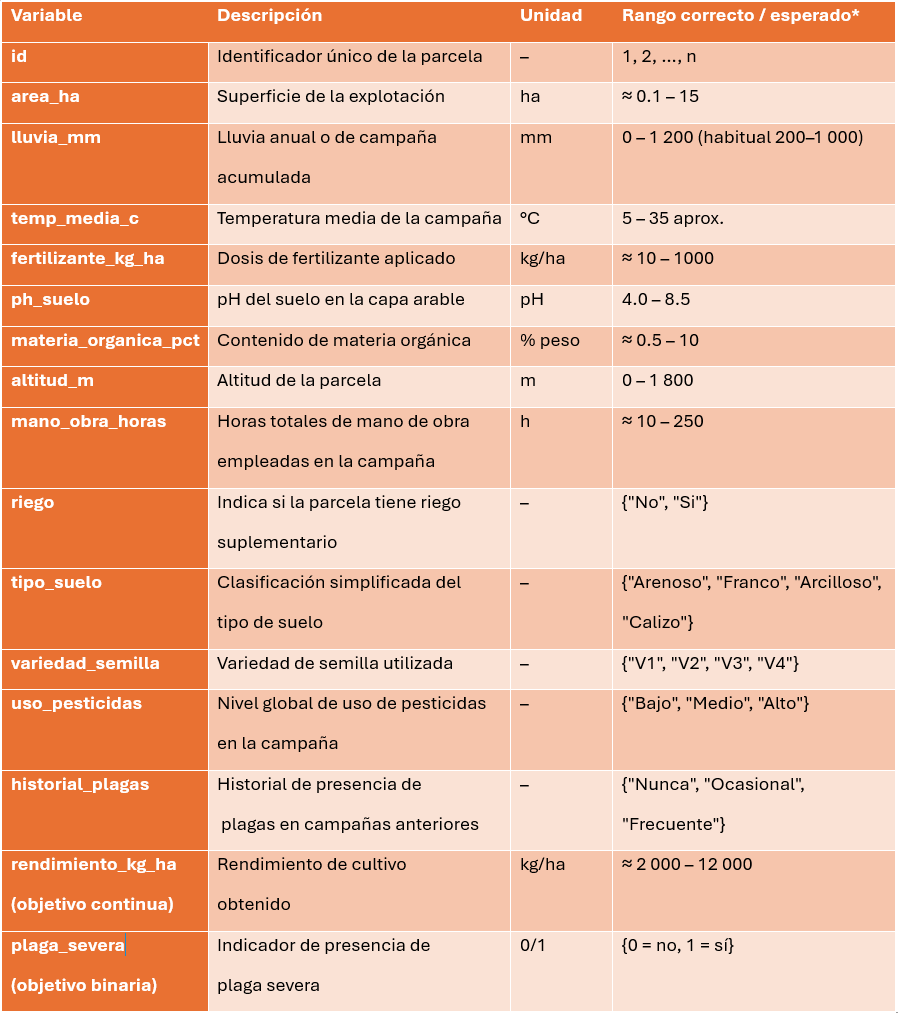

In [2]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/mineria/tarea_mineria/Tabla_Variables_Agri.png",width=600))

In [3]:
# Lectura datos agricultura
df = pd.read_csv("/content/drive/MyDrive/mineria/tarea_mineria/Datos_agricultura_25.csv")
# Lectura datos Ipi_Esp
df2 = pd.read_excel("/content/drive/MyDrive/mineria/tarea_mineria/IPI_Esp.xlsx")




## Depuración y regresiones

En esta primera parte se desarrolla la parte I del módulo que incluye depuración de datos y modelos de regresión lineal y logística.

Los datos a utilizar en esta parte son los contenidos en el conjunto **Datos_agricultura_25.csv**

### Pregunta 1

Comprobar que los datos siguen las especificaciones de **Tabla_variables_agri.png** y corregir los errores detectados asegurando tipos correctos. Justificar las decisiones que se toman.

Finalmente, separar las variables objetivo continua y binaria en objetos independientes y construir el input de predictores. ¿Alguna variable a eliminar en este momento?

In [4]:
# Comprobación datos :

df.head()
df.drop(columns=['Unnamed: 0'], inplace=True) #Drop de esta columna porque literalmente es la misma que el propio indice y ni aporta niguna información relevante.
df.head()


# Distribuciones de las variables corregidas


,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,rendimiento_kg_ha,plaga_severa
0,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca,6320.282655,0
1,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca,8011.839833,1
2,3,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente,6380.726608,1
3,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional,6969.167513,1
4,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente,6416.729743,1


In [5]:
# Corrección de errores
df.info()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3600 non-null   int64  
 1   area_ha               3600 non-null   float64
 2   lluvia_mm             3492 non-null   float64
 3   temp_media_c          3600 non-null   float64
 4   fertilizante_kg_ha    3600 non-null   float64
 5   ph_suelo              3564 non-null   float64
 6   materia_organica_pct  3528 non-null   float64
 7   altitud_m             3600 non-null   float64
 8   mano_obra_horas       3600 non-null   float64
 9   riego                 3600 non-null   object 
 10  tipo_suelo            3600 non-null   object 
 11  variedad_semilla      3600 non-null   object 
 12  uso_pesticidas        2880 non-null   object 
 13  historial_plagas      3600 non-null   object 
 14  rendimiento_kg_ha     3600 non-null   float64
 15  plaga_severa         

,0
id,3600
area_ha,3600
lluvia_mm,3483
temp_media_c,3591
fertilizante_kg_ha,3600
ph_suelo,3544
materia_organica_pct,3528
altitud_m,3451
mano_obra_horas,3593
riego,2


**Comentarios de proceso**
## - Cambios de tipos de variables : Las variables que son object hay que pasarlas a categóricas y la variable plaga_severa también.
##
...



In [6]:
# Lista de columnas con menos de 10 valores distintos. Potenciales factores
to_factor = list(df.loc[:,df.nunique() < 10]);

# Podemos cambiar el tipo de todas ellas a factor de una vez
df[to_factor] = df[to_factor].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    3600 non-null   int64   
 1   area_ha               3600 non-null   float64 
 2   lluvia_mm             3492 non-null   float64 
 3   temp_media_c          3600 non-null   float64 
 4   fertilizante_kg_ha    3600 non-null   float64 
 5   ph_suelo              3564 non-null   float64 
 6   materia_organica_pct  3528 non-null   float64 
 7   altitud_m             3600 non-null   float64 
 8   mano_obra_horas       3600 non-null   float64 
 9   riego                 3600 non-null   category
 10  tipo_suelo            3600 non-null   category
 11  variedad_semilla      3600 non-null   category
 12  uso_pesticidas        2880 non-null   category
 13  historial_plagas      3600 non-null   category
 14  rendimiento_kg_ha     3600 non-null   float64 
 15  plag

In [7]:
df.describe().round(2)#lluvia -50 y max 1350
#temp media max 60,fertilizante max 3.230,ph -1 y max 14,materia min y max mal,


,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,rendimiento_kg_ha
count,3600.00,3600.00,3492.00,3600.00,3600.00,3564.00,3528.00,3600.00,3600.00,3600.00
mean,1800.50,3.58,616.81,18.17,150.94,6.47,2.99,453.83,120.10,7112.24
std,1039.37,2.09,191.52,4.57,122.43,0.85,1.91,251.19,39.44,635.76
min,1.00,0.16,-50.00,4.08,10.63,-1.00,0.05,0.00,10.00,3444.27
25%,900.75,2.09,493.00,15.43,81.33,6.01,1.58,269.10,93.42,6722.79
50%,1800.50,3.17,616.64,18.06,122.54,6.49,2.56,449.86,120.88,7146.02
75%,2700.25,4.65,749.34,20.77,184.24,6.95,4.00,627.43,147.47,7547.97
max,3600.00,14.89,1301.29,60.00,3230.91,14.00,18.88,1329.74,242.06,9123.62


### Las variables continuas fuera de rango son lluvia, temp_media,fertilizante,ph y materia.

###Exploración y correción de la variable lluvia_mm, datos por debajo y por encima del rango de las variables que han sido mandados a missing porque son muy muy pocos valores los que están por encima o por debajo del rango. Y en ocasiones como los grados 60 está claro que es un error. En lluvia por debajo de 0 también se ha considerado como error.

/tmp/ipykernel_531/759998377.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='lluvia_mm',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='lluvia_mm', ylabel='rendimiento_kg_ha'>

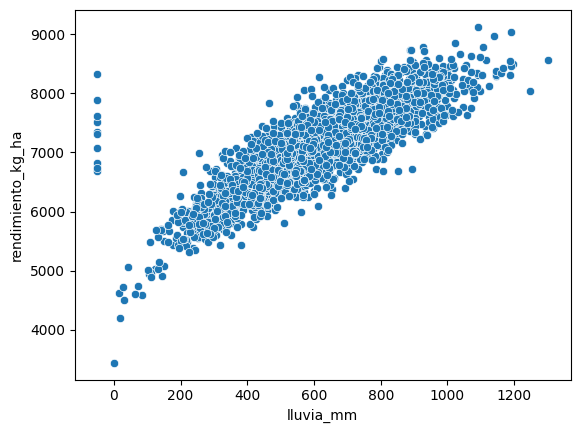

In [ ]:
sns.scatterplot(x='lluvia_mm',y="rendimiento_kg_ha",data=df, palette='viridis')

Minimum lluvia_mm: 0.0
Maximum lluvia_mm: 1195.8502360387238


/tmp/ipykernel_251/4183387294.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='lluvia_mm',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='lluvia_mm', ylabel='rendimiento_kg_ha'>

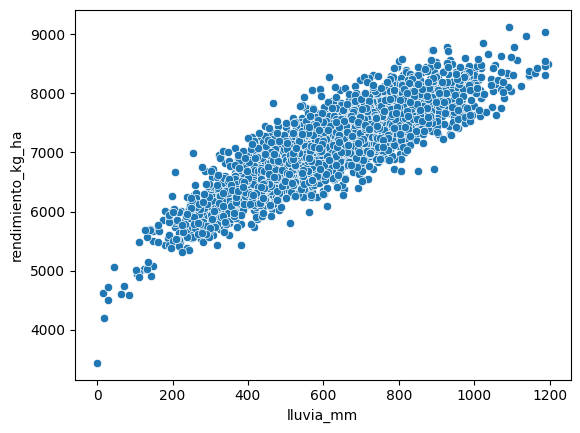

In [ ]:
#pasar a missings los valores fuera de rango para después imputar
df.loc[(df['lluvia_mm'] < 0) | (df['lluvia_mm'] > 1200), 'lluvia_mm'] = np.nan
#comprobamos que efectivamente ya no hay valores fuera de rango.
print(f"Minimum lluvia_mm: {df['lluvia_mm'].min()}")
print(f"Maximum lluvia_mm: {df['lluvia_mm'].max()}")
sns.scatterplot(x='lluvia_mm',y="rendimiento_kg_ha",data=df, palette='viridis')

 Los nuevos valores de lluvia están min 0 y max 1195

La siguiente variable es temp_media_c, hay muchos valores fuera de rango por encima de 35 que van a ser eliminados

/tmp/ipykernel_1194/601598332.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='temp_media_c',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='temp_media_c', ylabel='rendimiento_kg_ha'>

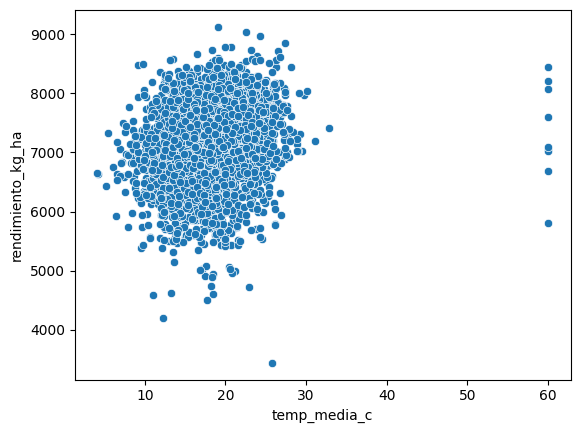

In [ ]:
sns.scatterplot(x='temp_media_c',y="rendimiento_kg_ha",data=df, palette='viridis')

Minimum temp_media_c: 4.084210725573882
Maximum temp_media_c: 32.8119039988551


/tmp/ipykernel_251/3007688128.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='temp_media_c',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='temp_media_c', ylabel='rendimiento_kg_ha'>

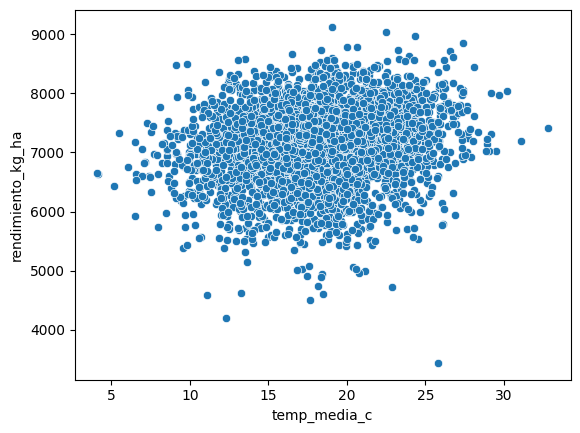

In [ ]:
df.loc[(df['temp_media_c'] > 35), 'temp_media_c'] = np.nan
#comprobamos que efectivamente ya no hay valores fuera de rango.
print(f"Minimum temp_media_c: {df['temp_media_c'].min()}")
print(f"Maximum temp_media_c: {df['temp_media_c'].max()}")
sns.scatterplot(x='temp_media_c',y="rendimiento_kg_ha",data=df, palette='viridis')

Variable temp ha sido corregida los valores minimos son 4 y max 32

Fertilizante tiene valores por encima de su max que es 1000

/tmp/ipykernel_1194/3054643304.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='fertilizante_kg_ha',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='fertilizante_kg_ha', ylabel='rendimiento_kg_ha'>

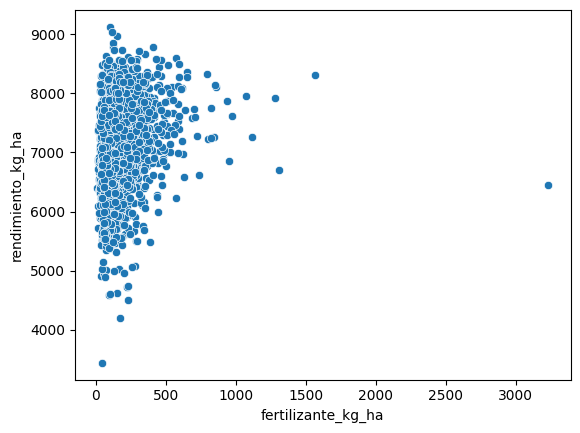

In [ ]:
sns.scatterplot(x='fertilizante_kg_ha',y="rendimiento_kg_ha",data=df, palette='viridis')

Minimum fertilizante_kg_ha: 10.631404661227403
Maximum fertilizante_kg_ha: 976.8525643954908


/tmp/ipykernel_251/3075900043.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='fertilizante_kg_ha',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='fertilizante_kg_ha', ylabel='rendimiento_kg_ha'>

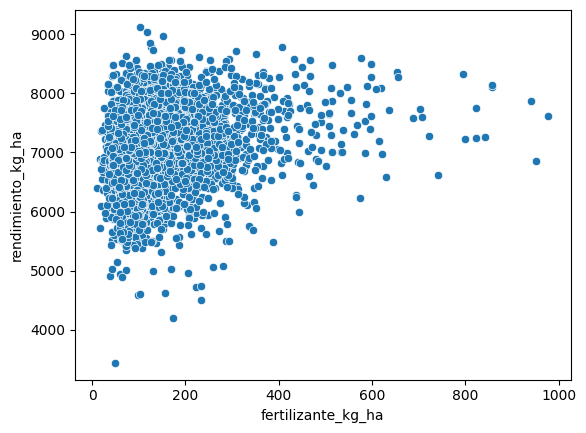

In [ ]:

df.loc[(df['fertilizante_kg_ha'] > 1000), 'fertilizante_kg_ha'] = np.nan
print(f"Minimum fertilizante_kg_ha: {df['fertilizante_kg_ha'].min()}")
print(f"Maximum fertilizante_kg_ha: {df['fertilizante_kg_ha'].max()}")
sns.scatterplot(x='fertilizante_kg_ha',y="rendimiento_kg_ha",data=df, palette='viridis')


Valores fuera de rango imputados porque ni como putlier un valor de 3500 tiene sentido en este escenario, y el resto de valores se pueden ajustar cuando hagamos las imputaciones ya que estaban muy próximos a 1000

Variable ph, valores fuera de rango, como en el resto de variables ajustar al rango.

/tmp/ipykernel_1194/235828086.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='ph_suelo',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='ph_suelo', ylabel='rendimiento_kg_ha'>

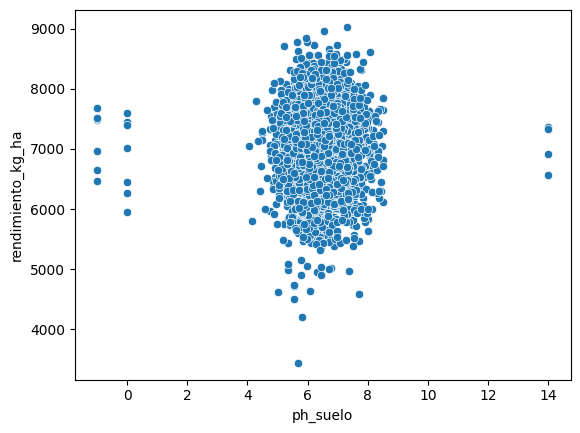

In [ ]:
sns.scatterplot(x='ph_suelo',y="rendimiento_kg_ha",data=df, palette='viridis')

Minimum ph_suelo: 4.06609179137347
Maximum ph_suelo: 8.5


/tmp/ipykernel_251/3792128939.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='ph_suelo',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='ph_suelo', ylabel='rendimiento_kg_ha'>

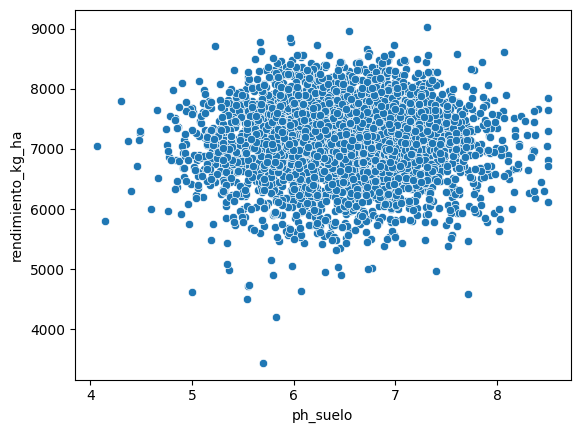

In [ ]:
df.loc[(df['ph_suelo'] < 4.0) | (df['ph_suelo'] > 8.5), 'ph_suelo'] = np.nan
print(f"Minimum ph_suelo: {df['ph_suelo'].min()}")
print(f"Maximum ph_suelo: {df['ph_suelo'].max()}")
sns.scatterplot(x='ph_suelo',y="rendimiento_kg_ha",data=df, palette='viridis')

Variable ph dentro de rango

/tmp/ipykernel_531/1194077510.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='materia_organica_pct',y="rendimiento_kg_ha",data=df, palette='viridis')


<Axes: xlabel='materia_organica_pct', ylabel='rendimiento_kg_ha'>

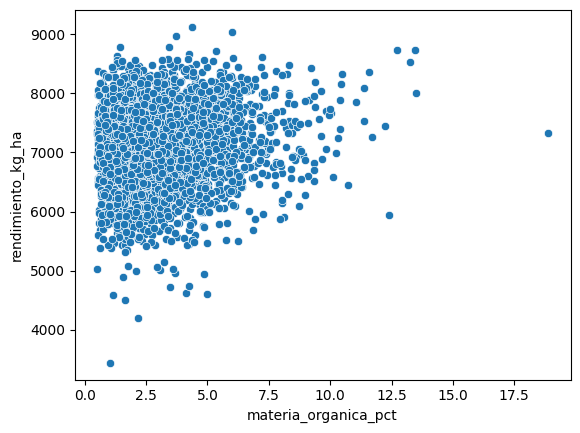

In [ ]:
sns.scatterplot(x='materia_organica_pct',y="rendimiento_kg_ha",data=df, palette='viridis')

Minimum materia_organica_pct: 0.5033074086483676
Maximum materia_organica_pct: 9.949349145769832


/tmp/ipykernel_251/3911498129.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='materia_organica_pct', y="rendimiento_kg_ha", data=df, palette='viridis')


(0.5, 10.0)

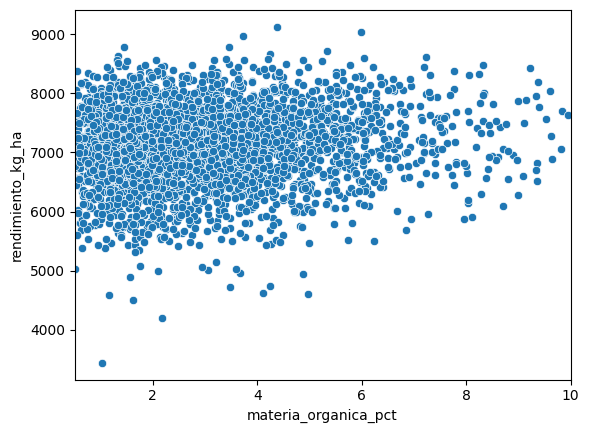

In [ ]:
# Filtrar valores fuera del rango 0.5-10
df.loc[(df['materia_organica_pct'] < 0.5) | (df['materia_organica_pct'] > 10), 'materia_organica_pct'] = np.nan

print(f"Minimum materia_organica_pct: {df['materia_organica_pct'].min()}")
print(f"Maximum materia_organica_pct: {df['materia_organica_pct'].max()}")

# Crear el scatter plot
sns.scatterplot(x='materia_organica_pct', y="rendimiento_kg_ha", data=df, palette='viridis')

# Opcional: establecer límites claros en el eje x
plt.xlim(0.5, 10)

variable materia_organica_pct solucionada y dentro de rango.Una vez terminada la exploración y el arreglo de las numéricas podemos ir a por las variable categóricas.

Arreglo de distribuciones y Arreglo de variables categóricas, en busca de errores.

In [8]:
df.nunique()

,0
id,3600
area_ha,3600
lluvia_mm,3483
temp_media_c,3591
fertilizante_kg_ha,3600
ph_suelo,3544
materia_organica_pct,3528
altitud_m,3451
mano_obra_horas,3593
riego,2


Estudio de las distribuciones de las variables, vemos que son correctas pero que suelo tiene un error





Cont


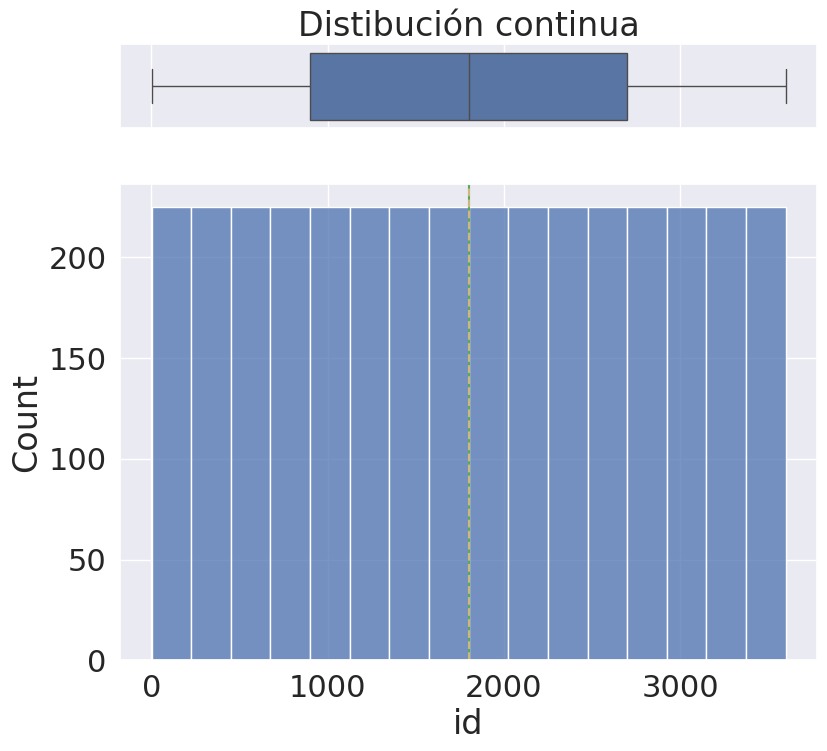

Cont


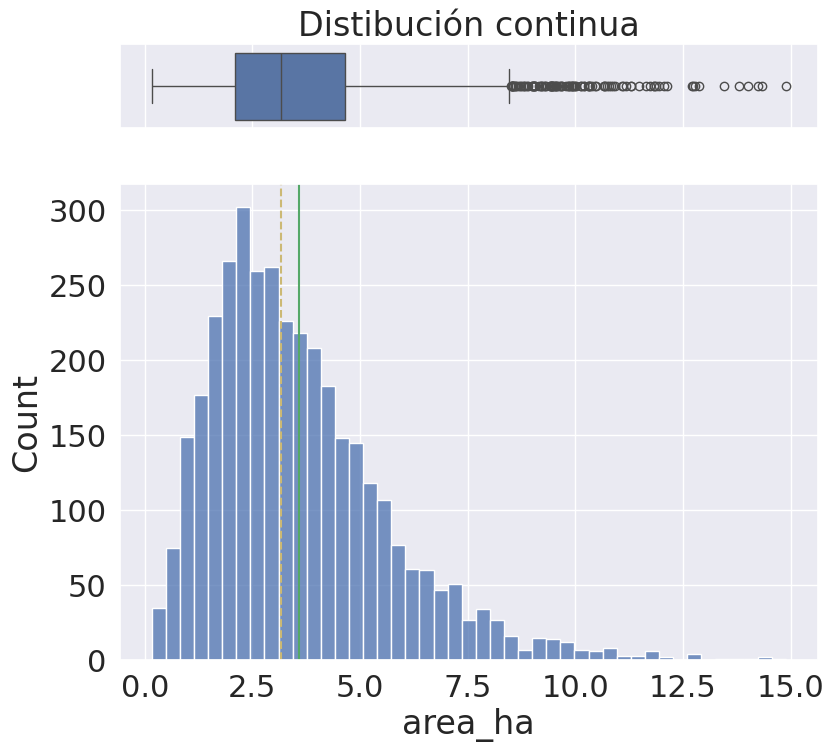

Cont


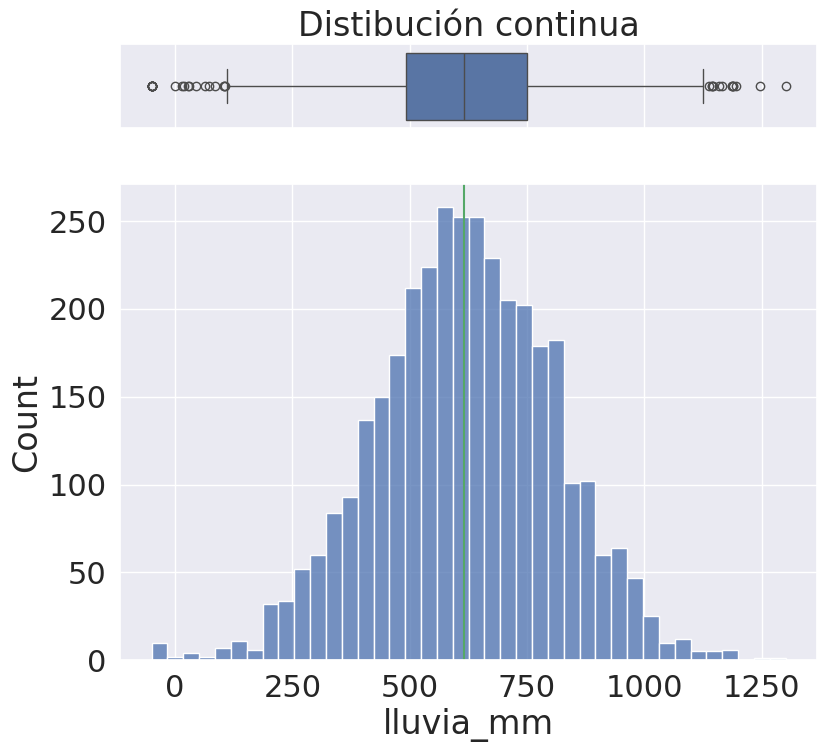

Cont


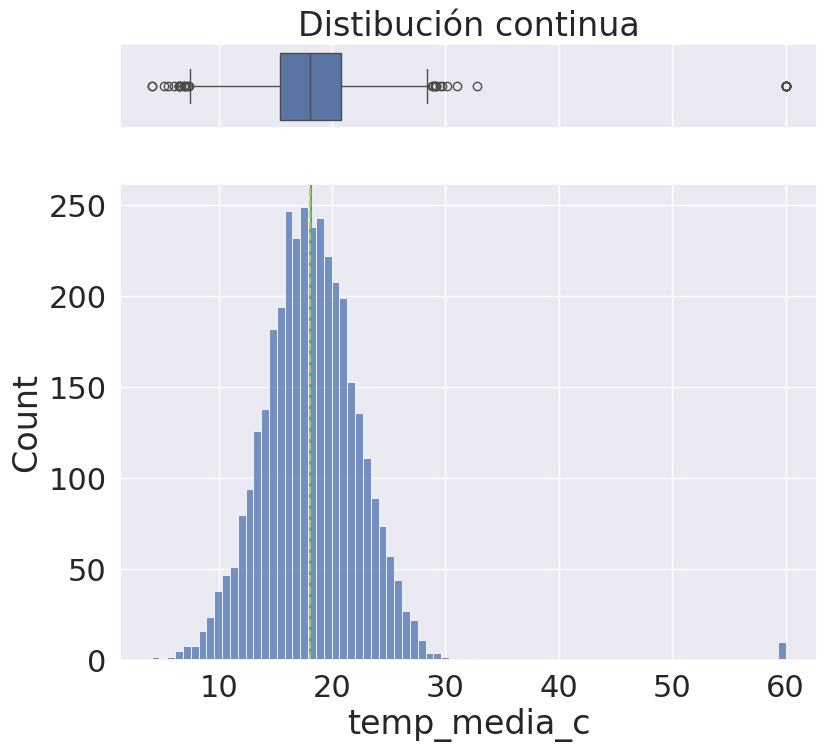

Cont


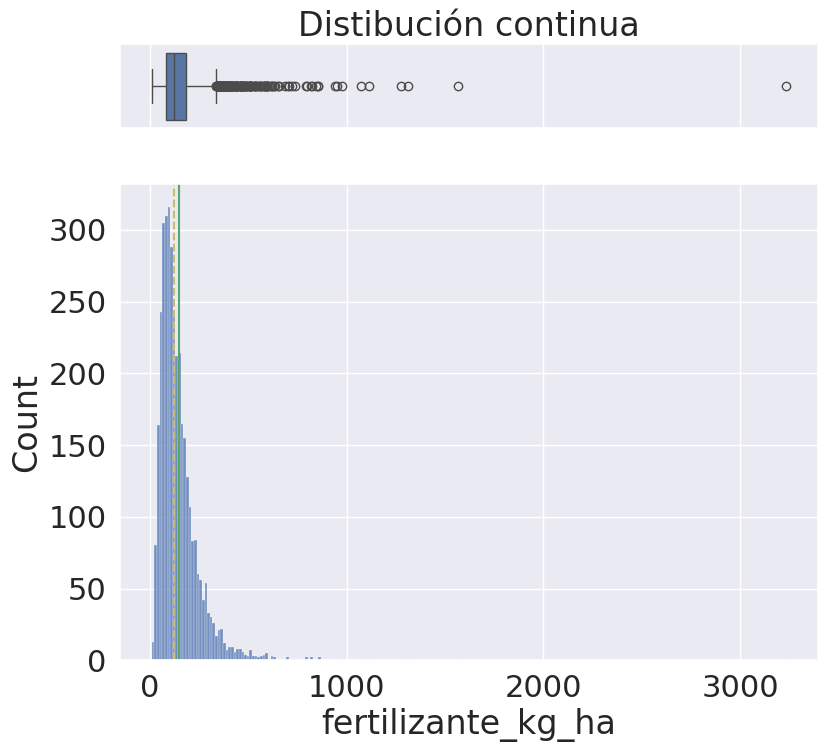

Cont


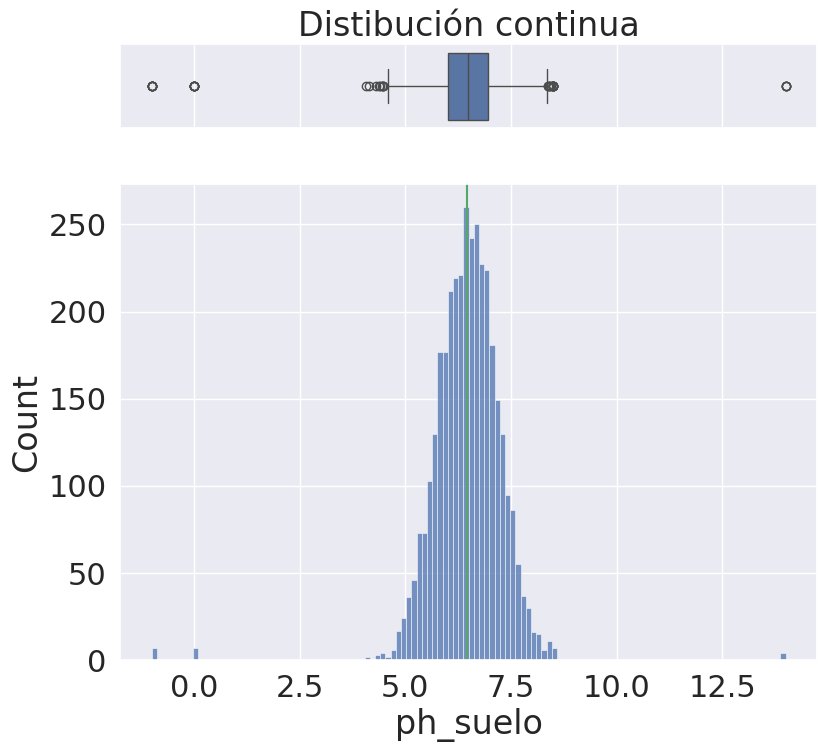

Cont


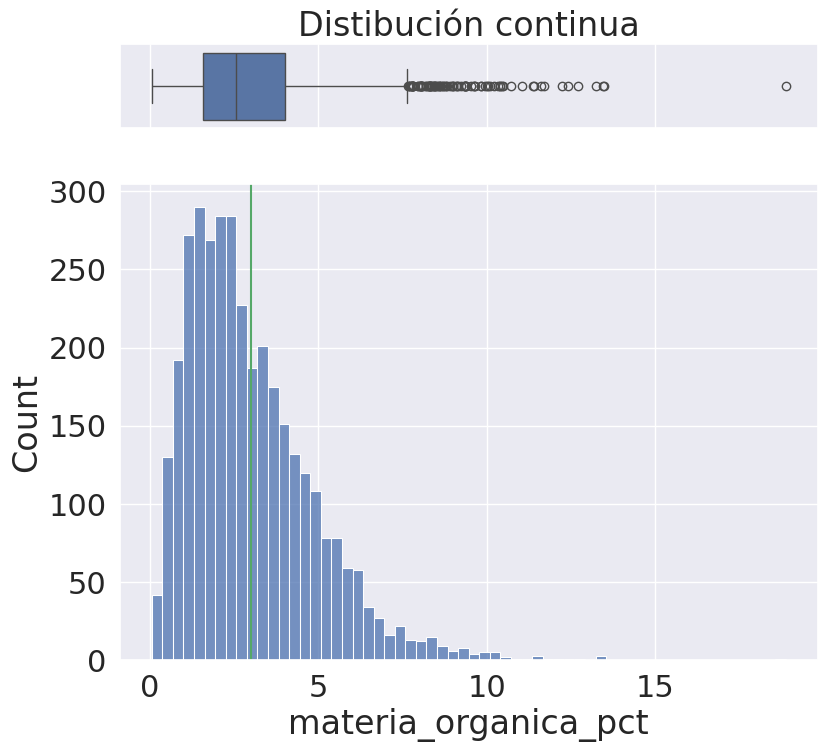

Cont


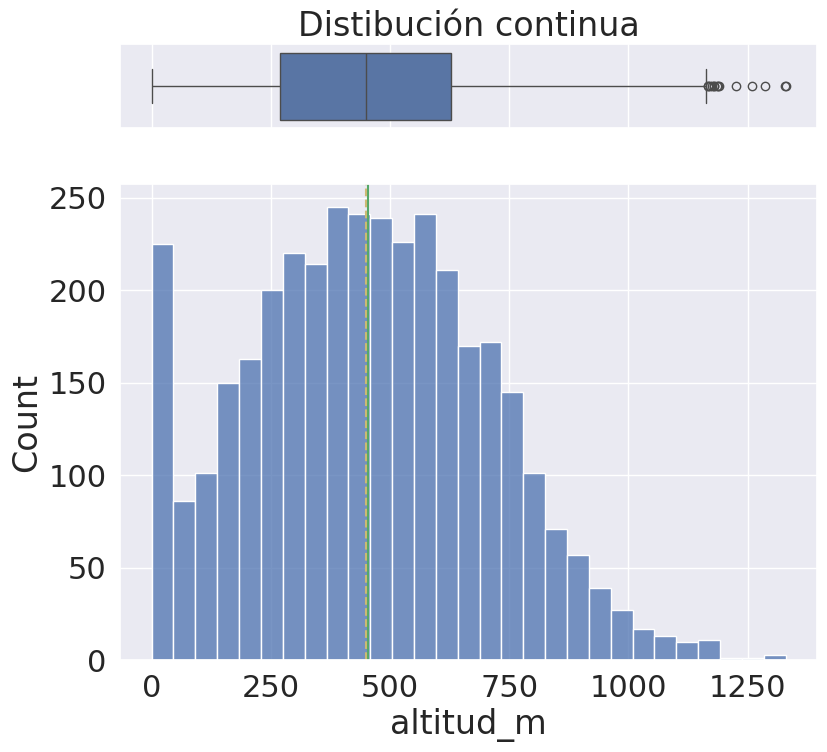

Cont


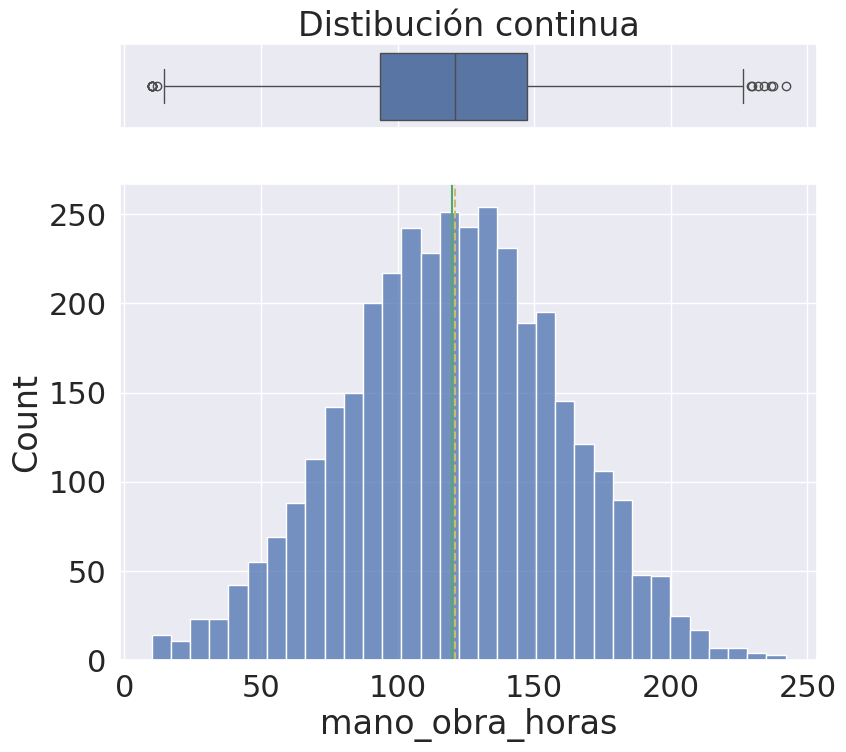

Cat


Cat


Cat


Cat


Cat


Cont


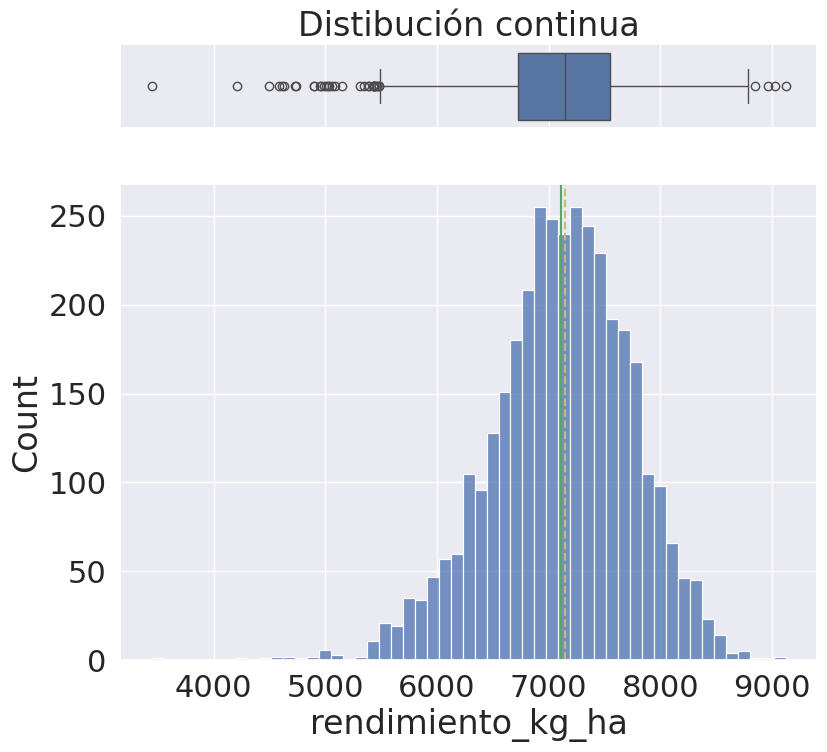

Cat


,0
id,None
area_ha,None
lluvia_mm,None
temp_media_c,None
fertilizante_kg_ha,None
ph_suelo,None
materia_organica_pct,None
altitud_m,None
mano_obra_horas,None
riego,None


In [9]:

df.apply(plot)

Arreglo tipo de suelo , unir las minoritarias con menor count a las mayoritarias de mayor count de la categoría Franco.

Value counts before standardization:
tipo_suelo
Franco       1307
Arcilloso     901
Arenoso       886
Calizo        367
 Franco       139
Name: count, dtype: int64

Value counts after standardization:
tipo_suelo
Franco       1446
Arcilloso     901
Arenoso       886
Calizo        367
Name: count, dtype: int64


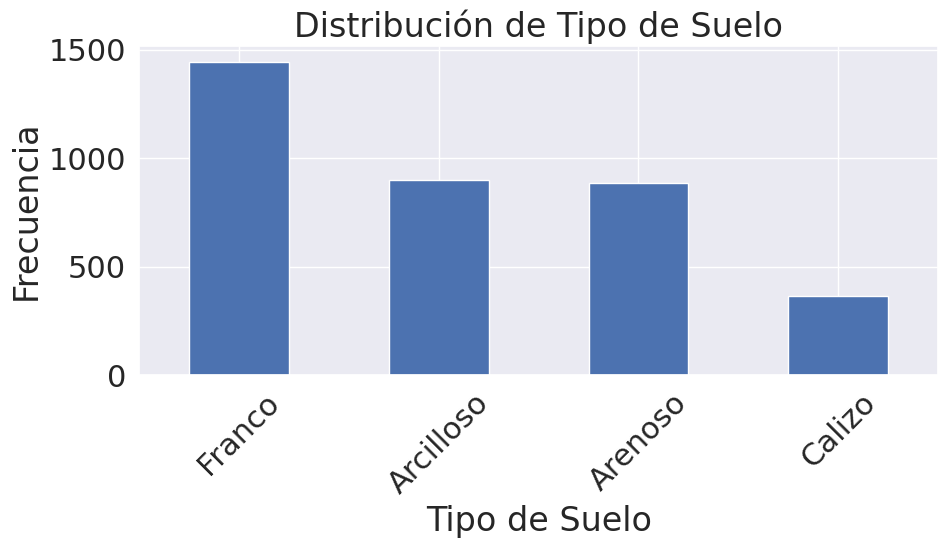

In [10]:
print("Value counts before standardization:")
print(df['tipo_suelo'].value_counts())

# Standardize 'tipo_suelo' entries: convert to string, strip whitespace, convert to lowercase, then capitalize the first letter.
df['tipo_suelo'] = df['tipo_suelo'].astype(str).str.strip().str.capitalize()

# Show updated value counts for 'tipo_suelo'
print("\nValue counts after standardization:")
print(df['tipo_suelo'].value_counts())

# bar plot
plt.figure(figsize=(10, 6))
df['tipo_suelo'].value_counts().plot(kind='bar')
plt.title('Distribución de Tipo de Suelo')
plt.xlabel('Tipo de Suelo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


He juntado la variable Franco con 139 count a la que tiene más count para que quede solo una y que cumpla con los requerimientos de la tabla de variables. Solucionando el error que había de dos Franco

Una vez libre de errores,sigo explorando las variables categóricas, ahora para ver si el modelo puede aprender de cada una de las categorías de cada categórica y que estén compensadas. Las comparo con la objetivo continua.

In [11]:
df.riego.value_counts()

,count
riego,
No,1977
Si,1623


/tmp/ipykernel_4305/1739574217.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='riego', ylabel='rendimiento_kg_ha'>

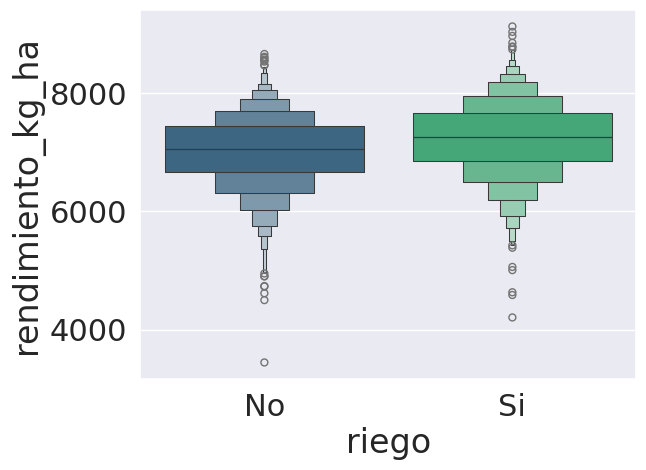

In [12]:

sns.boxenplot(data=df, x='riego', y='rendimiento_kg_ha', palette='viridis')

Observo como ambas están compensadas por tanto podrá aprender correctamente de ellas el modelo. Y además vamos comprendiendo las relaciones con la variable objetivo, cuanto más riego aprece que hay un mejor rendimiento, como era esperable.

In [13]:
df.tipo_suelo.value_counts()

,count
tipo_suelo,
Franco,1446
Arcilloso,901
Arenoso,886
Calizo,367


/tmp/ipykernel_4305/284636348.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='tipo_suelo', ylabel='rendimiento_kg_ha'>

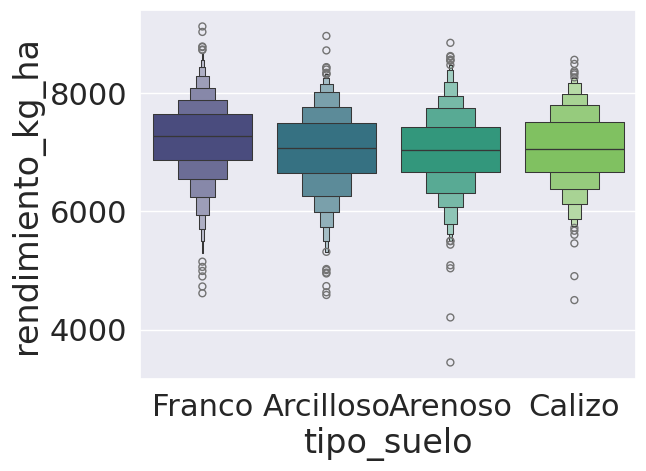

In [14]:

sns.boxenplot(data=df, x='tipo_suelo', y='rendimiento_kg_ha', palette='viridis')

Como vemos las 4 clases están balanceadas y tienen un número suficiente de observaciones de las que podrá aprender el modelo correctamente.



In [15]:
df.variedad_semilla.value_counts()

,count
variedad_semilla,
V2,1266
V1,917
V3,911
V4,506


/tmp/ipykernel_4305/2352040728.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='variedad_semilla', ylabel='rendimiento_kg_ha'>

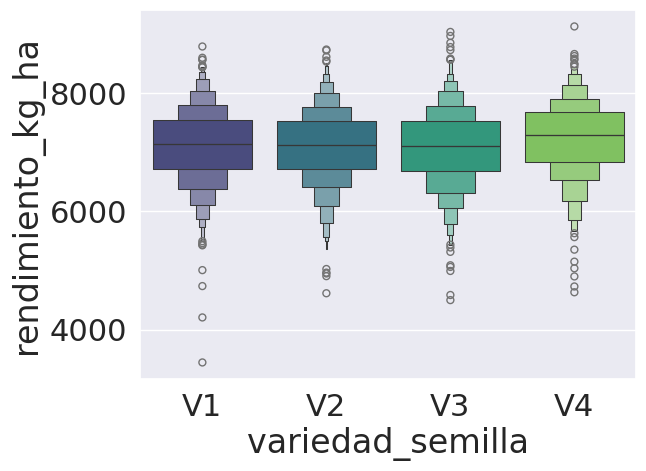

In [16]:

sns.boxenplot(data=df, x='variedad_semilla', y='rendimiento_kg_ha', palette='viridis')

De nuevo , clases bastante bien balanceadas salvo por v4 que tiene algunas obseervaciones menos.

In [17]:
df.uso_pesticidas.value_counts()

,count
uso_pesticidas,
Bajo,1391
Medio,1041
Alto,448


/tmp/ipykernel_4305/1908742744.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='uso_pesticidas', ylabel='rendimiento_kg_ha'>

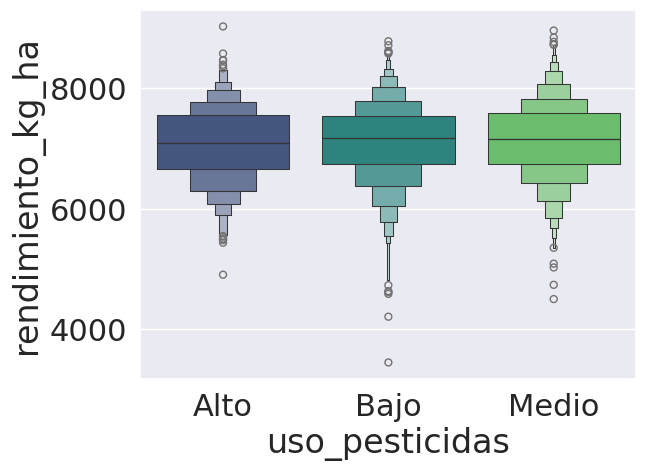

In [18]:

sns.boxenplot(data=df, x='uso_pesticidas', y='rendimiento_kg_ha', palette='viridis')

In [19]:
df.historial_plagas.value_counts()

,count
historial_plagas,
Nunca,2156
Ocasional,1069
Frecuente,375


/tmp/ipykernel_4305/4016831302.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='historial_plagas', ylabel='rendimiento_kg_ha'>

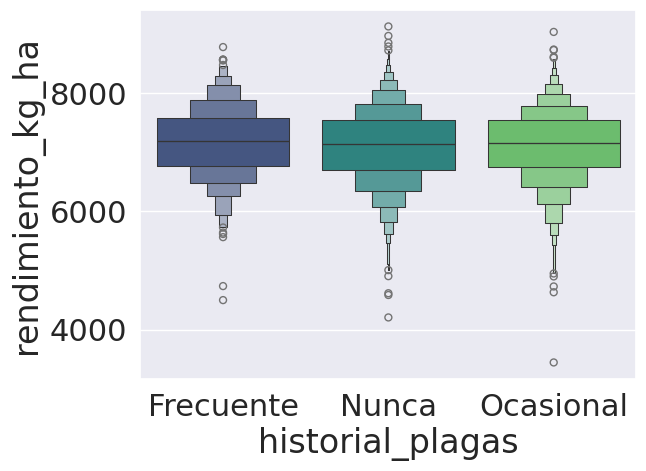

In [20]:

sns.boxenplot(data=df, x='historial_plagas', y='rendimiento_kg_ha', palette='viridis')

Todas las categorías tienen las suficinetes observaciones para que el modelo aprenda de ellas. Aunque frecuente tenga un número más reducido.

### Pregunta 2

Genera tu proceso de depuración de los datos incluyendo análisis y gestión de outliers y de missings. Deberás tomar decisiones y justificarlas adecuadamente.

Al final del proceso se debe obtener un conjunto de datos depurado con todas las observaciones y variables válidas para modelo, presentando los descriptivos y comentado los cambios realizados y las razones de dichas actuaciones.

Outliers:

In [21]:
# Separar variables objetivo
var_objcont = df.rendimiento_kg_ha
var_objbin = df.plaga_severa
# Crear input de predictores
input = df.drop(columns=['rendimiento_kg_ha','plaga_severa']) # input todos los prodictores excluyendo los objetivos, paso intermedio
#Crear inputts continuas para luego pasar la función de outliers
input_cont = input.select_dtypes(include=np.number) #uso el input anterior y me quedo con las continuas
input_cont.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3600 non-null   int64  
 1   area_ha               3600 non-null   float64
 2   lluvia_mm             3492 non-null   float64
 3   temp_media_c          3600 non-null   float64
 4   fertilizante_kg_ha    3600 non-null   float64
 5   ph_suelo              3564 non-null   float64
 6   materia_organica_pct  3528 non-null   float64
 7   altitud_m             3600 non-null   float64
 8   mano_obra_horas       3600 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 253.3 KB


In [22]:
tab_out = input_cont.apply(lambda x: gestiona_outliers(x))#c gestiona outliers de la x cuenta porcentaje de outliers por cada variable, solo numéricos. es un diagnositco se aplica en la casilla despues
tab_out.index = ['%Low','%High','%Tot'] #por ponerlo más informativo
tab_out.round(2)

id
area_ha
lluvia_mm
temp_media_c
fertilizante_kg_ha
ph_suelo
materia_organica_pct
altitud_m
mano_obra_horas


,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas
%Low,0.0,0.00,0.0,0.00,0.00,0.39,0.00,0.0,0.0
%High,0.0,0.28,0.0,0.28,1.64,0.11,0.31,0.0,0.0
%Tot,0.0,0.28,0.0,0.28,1.64,0.51,0.31,0.0,0.0


In [23]:
# Gestión efectiva outliers con paso a missings, los paso a missings, solo correrla una vez
input_cont_mis = input_cont.apply(lambda x: gestiona_outliers(x, clas='miss'))


id

 MissingAntes: 0
MissingDespues: 0

area_ha

 MissingAntes: 0
MissingDespues: 10

lluvia_mm

 MissingAntes: 108
MissingDespues: 108

temp_media_c

 MissingAntes: 0
MissingDespues: 10

fertilizante_kg_ha

 MissingAntes: 0
MissingDespues: 59

ph_suelo

 MissingAntes: 36
MissingDespues: 54

materia_organica_pct

 MissingAntes: 72
MissingDespues: 83

altitud_m

 MissingAntes: 0
MissingDespues: 0

mano_obra_horas

 MissingAntes: 0
MissingDespues: 0



Por un parte podría winsorizar  porque según he hecho el EDA y ajustado los valores a la tabla me parece que los ouliers restantes son valores reales y no datos que directamente quiera madnar a missing, pero como vemos son muy pocos se puede mandar a missing sin problema y luego gestionar todo allí.

**Comentarios**:

...

Gestión de missings.

In [24]:
# Unir variables categóricas,# Juntar categóricas para contar incidencia de missings (total) sacar el total
input_mis = input_cont_mis.join(input.select_dtypes(exclude=np.number)) #gestión paso a missing, distribución sin outliers, uno las numéricas a las categóricas
input_mis.info()



# Incidencia de missings

# Gestión efectiva de missings


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    3600 non-null   float64 
 1   area_ha               3590 non-null   float64 
 2   lluvia_mm             3492 non-null   float64 
 3   temp_media_c          3590 non-null   float64 
 4   fertilizante_kg_ha    3541 non-null   float64 
 5   ph_suelo              3546 non-null   float64 
 6   materia_organica_pct  3517 non-null   float64 
 7   altitud_m             3600 non-null   float64 
 8   mano_obra_horas       3600 non-null   float64 
 9   riego                 3600 non-null   category
 10  tipo_suelo            3600 non-null   object  
 11  variedad_semilla      3600 non-null   category
 12  uso_pesticidas        2880 non-null   category
 13  historial_plagas      3600 non-null   category
dtypes: category(4), float64(9), object(1)
memory usage: 296.

Por algun motivo que desconozco tipo_suelo aparece como object cuando arriba del todo la puse como category asi que la vuelvo a cambiar.

In [25]:
input_mis['tipo_suelo'] = input_mis['tipo_suelo'].astype('category')
input_mis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    3600 non-null   float64 
 1   area_ha               3590 non-null   float64 
 2   lluvia_mm             3492 non-null   float64 
 3   temp_media_c          3590 non-null   float64 
 4   fertilizante_kg_ha    3541 non-null   float64 
 5   ph_suelo              3546 non-null   float64 
 6   materia_organica_pct  3517 non-null   float64 
 7   altitud_m             3600 non-null   float64 
 8   mano_obra_horas       3600 non-null   float64 
 9   riego                 3600 non-null   category
 10  tipo_suelo            3600 non-null   category
 11  variedad_semilla      3600 non-null   category
 12  uso_pesticidas        2880 non-null   category
 13  historial_plagas      3600 non-null   category
dtypes: category(5), float64(9)
memory usage: 271.6 KB


In [26]:
# Contar incidencia de missings por registro
input_mis.apply(lambda x: x.isna().sum()/input_mis.shape[0]*100).round(2) #si eres perdido suma


,0
id,0.00
area_ha,0.28
lluvia_mm,3.00
temp_media_c,0.28
fertilizante_kg_ha,1.64
ph_suelo,1.50
materia_organica_pct,2.31
altitud_m,0.00
mano_obra_horas,0.00
riego,0.00


Estos missings vienen desde el comienzo pero podemos situarlos como desconocidos para que el modelo pueda aprender de ellos.

In [27]:
# Primero agregar la nueva categoría
input_mis['uso_pesticidas'] = input_mis['uso_pesticidas'].cat.add_categories(['Desconocido'])

# Ahora imputar (funciona porque 'Desconocido' ya es categoría válida)
input_mis['uso_pesticidas'] = input_mis['uso_pesticidas'].fillna('Desconocido')

In [28]:
#veriricar después de esta imputación de pasarlo a desconocidos
print("\nPorcentaje de missings después de pasar a desconocido:")
print((input_mis['uso_pesticidas'].isna().sum() / len(input_mis) * 100).round(2))


Porcentaje de missings después de pasar a desconocido:
0.0


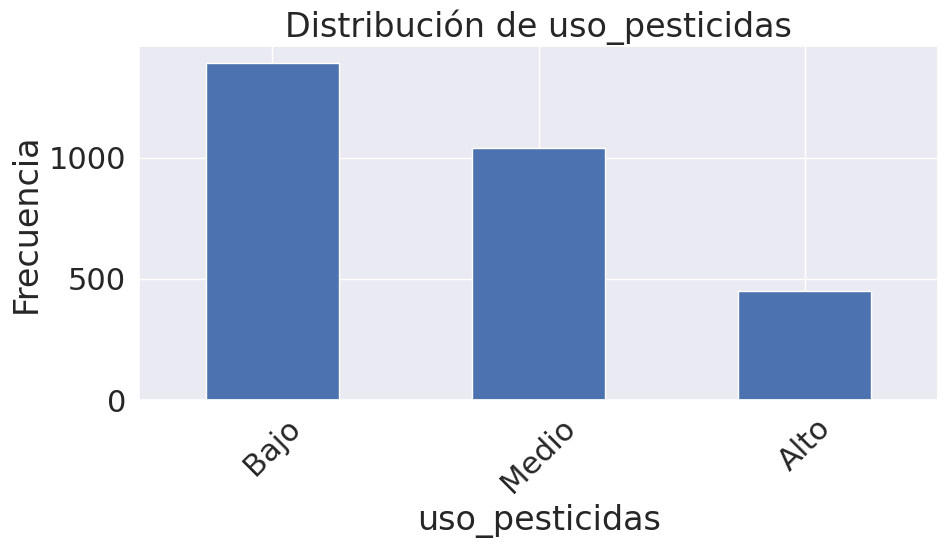

In [29]:
# Generate bar plot for 'uso_pesticidas'
plt.figure(figsize=(10, 6))
df['uso_pesticidas'].value_counts().plot(kind='bar')
plt.title('Distribución de uso_pesticidas')
plt.xlabel('uso_pesticidas')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Axes: >

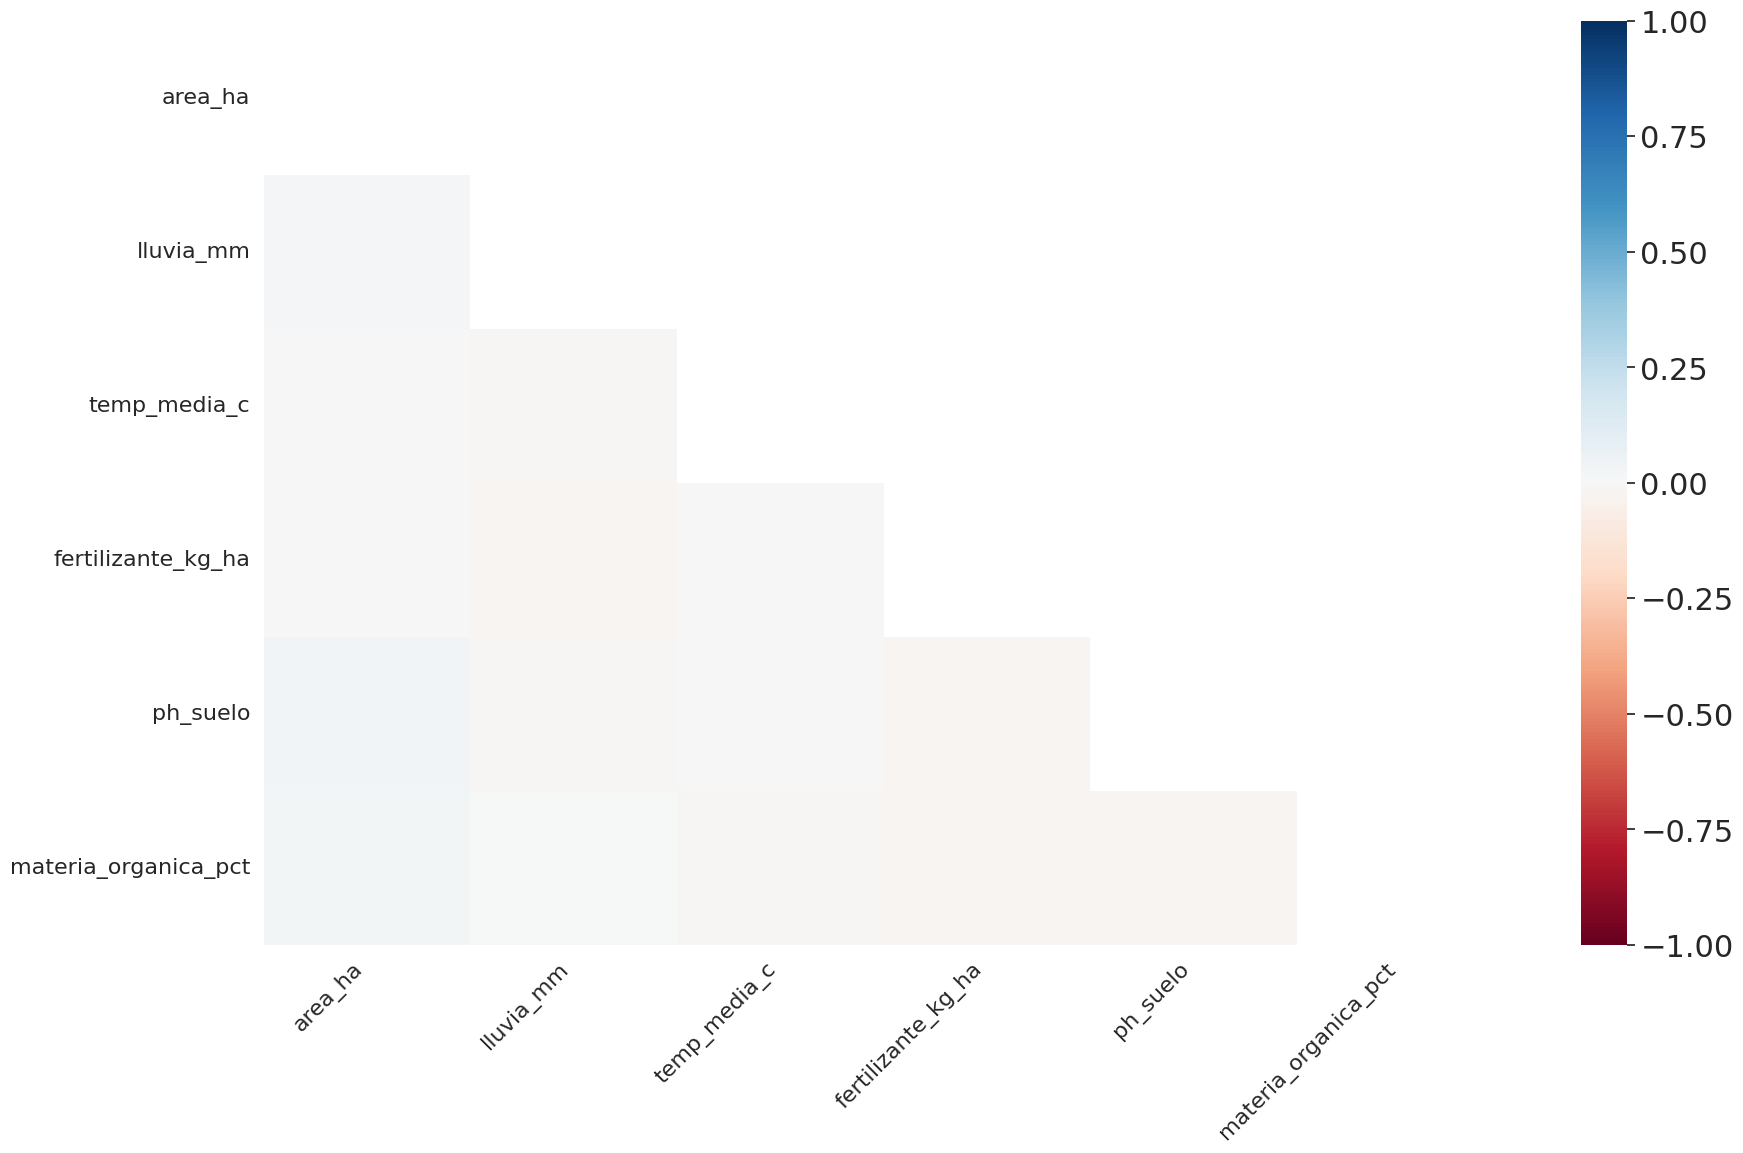

In [30]:
import missingno as msno
msno.heatmap(input_mis)

No veo color en ninguna por tanto no hay patrones de missings. Valores muy débiles en todo el rango.

Imputaciones :

In [31]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.2 MB/s eta 0:00:00


In [32]:
# Imputaciones, defino imputadores
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer

# Chain equations: solo numéricas
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)#definir el modelo preparado para actuar

# Cargar paquete imputer random
import feature_engine.imputation as fe_imp

# Aleatoria: numéricas y nominales
imputer_rand = fe_imp.RandomSampleImputer()

In [33]:
#separar variables
#seleccionar categóricas :
cat = input_mis.select_dtypes(exclude=np.number)#selecciona solo las categóricas
cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   riego             3600 non-null   category
 1   tipo_suelo        3600 non-null   category
 2   variedad_semilla  3600 non-null   category
 3   uso_pesticidas    3600 non-null   category
 4   historial_plagas  3600 non-null   category
dtypes: category(5)
memory usage: 18.6 KB


In [34]:
# Seleccionar continuas
cont = input_mis.select_dtypes(include=np.number)#selecc continuas
cont.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3600 non-null   float64
 1   area_ha               3590 non-null   float64
 2   lluvia_mm             3492 non-null   float64
 3   temp_media_c          3590 non-null   float64
 4   fertilizante_kg_ha    3541 non-null   float64
 5   ph_suelo              3546 non-null   float64
 6   materia_organica_pct  3517 non-null   float64
 7   altitud_m             3600 non-null   float64
 8   mano_obra_horas       3600 non-null   float64
dtypes: float64(9)
memory usage: 253.3 KB


In [35]:
# Imputación de continuas por cadenas de markov (regresión)
con_imputed = pd.DataFrame(imputer_itImp.fit_transform(cont), columns=cont.columns)#fit_tranform aplicas el imputador y cont los datos que quiero imputar
con_imputed.info()#todo 5000 relleno todo bien

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3600 non-null   float64
 1   area_ha               3600 non-null   float64
 2   lluvia_mm             3600 non-null   float64
 3   temp_media_c          3600 non-null   float64
 4   fertilizante_kg_ha    3600 non-null   float64
 5   ph_suelo              3600 non-null   float64
 6   materia_organica_pct  3600 non-null   float64
 7   altitud_m             3600 non-null   float64
 8   mano_obra_horas       3600 non-null   float64
dtypes: float64(9)
memory usage: 253.3 KB


In [36]:
# Imputación de categóricas por random (podría ser moda...)
cat_imputed = imputer_rand.fit_transform(cat)
cat_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   riego             3600 non-null   category
 1   tipo_suelo        3600 non-null   category
 2   variedad_semilla  3600 non-null   category
 3   uso_pesticidas    3600 non-null   category
 4   historial_plagas  3600 non-null   category
dtypes: category(5)
memory usage: 18.6 KB


In [37]:
# Archivo final juntar las variables continuas de con categoricas con las objetivo, que son varobj,varobjcont y varobjbin que aparecen entre ()
df_mis_ItImp_random = pd.concat([con_imputed, cat_imputed, var_objcont,var_objbin,], axis=1)

In [38]:
#Como ha quedado el archivo final
df_mis_ItImp_random.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    3600 non-null   float64 
 1   area_ha               3600 non-null   float64 
 2   lluvia_mm             3600 non-null   float64 
 3   temp_media_c          3600 non-null   float64 
 4   fertilizante_kg_ha    3600 non-null   float64 
 5   ph_suelo              3600 non-null   float64 
 6   materia_organica_pct  3600 non-null   float64 
 7   altitud_m             3600 non-null   float64 
 8   mano_obra_horas       3600 non-null   float64 
 9   riego                 3600 non-null   category
 10  tipo_suelo            3600 non-null   category
 11  variedad_semilla      3600 non-null   category
 12  uso_pesticidas        3600 non-null   category
 13  historial_plagas      3600 non-null   category
 14  rendimiento_kg_ha     3600 non-null   float64 
 15  plag

El cambio más importante que he realizado ha sido el de pasar los missings a Desconocido ya que era un porcentaje (20) por encima de lo esperado. Del resto no me he preocupado ni he tirado ningún describe post imputaciones porque el porcentaje de missings era muy bajo. Si huviera tenido una variable con por ejemplo un 10% de missings habría tirado dos describe, para ver como ha cambiado tras la imputación y poder ver coas destacadas como si ha cambiado la media y la desviación standard.

En el caso de la variable con un porcentaje tan elevado he preferido pasarlo a desconocido para que el modelo pueda aprender de ella en vez de dar por perdido el 20 % de los datos que me parece demasiado.

Para las variables numéricas he utilizado las ecuaciones encadenadas de Markov principalmente por el motivo de que en clase se dijo que normalmente era el método más utilizado y que con el se obtenían buenos resultados. Además también me ha llevado a investigar e interesarme más sobre las propias Cadenas de Markov para saber mejor su funcionamiento y conocer otras aplicaciones ya que siempre había esuchado que tenían gran prevalencia en el mundillo data.

Para las variables continuas he utilizado el método rand tratando de no subestimar la varianza de la distribución a pesar de que dependa del azar, lo que a su vez abre un debate muy interesante sobre la no existencia del azar en los ordenadores, pero bueno, eso ya es otro tema.

### Pregunta 3

Generar dos variables aleatorias de control. Presentar el ranking de variables basado en la V de Cramer para todos los predictores frente a la variable objetivo continua. ¿Cuáles son las variables que consideras podrían ser importantes para el modelo?

In [39]:
# Generar aleatorios
df_mis_ItImp_random['aleatorio'] = np.random.uniform(0,1,size=df.shape[0]) #vector aleatorio de longitud como el dataset.
df_mis_ItImp_random['aleatorio2'] = np.random.uniform(0,1,size=df.shape[0])
df.head()



,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,rendimiento_kg_ha,plaga_severa
0,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca,6320.282655,0
1,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca,8011.839833,1
2,3,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente,6380.726608,1
3,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional,6969.167513,1
4,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente,6416.729743,1


In [40]:
# Ranking V de Cramer vs. obj, uso el df limpio con las imputaciones
tablaCramer = pd.DataFrame(df_mis_ItImp_random.drop(['rendimiento_kg_ha','plaga_severa'],axis=1).apply(lambda x: cramers_v(x,df_mis_ItImp_random.rendimiento_kg_ha)),columns=['VCramer']) #dropeo las variable objetivo

import plotly.express as px
px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones frente a FEV').update_yaxes(categoryorder="total ascending")

Las más importantes para el modelo sin duda sería lluvia y luego tambíen añadiría riego y fertilizante.Pero no me iría más abajo.

**Respuesta**:

...

### Pregunta 4

Ajustar el modelo completo de referencia para la predicción de la variable objetivo continua.

- ¿Cuál es el valor de $R^2$? ¿Qué interpretación tiene?
- ¿Qué hipótesis nula maneja el contraste general del modelo? Interpreta en este caso.
- ¿Cuántos efectos tiene el modelo sin contar la constante? ¿Cuántos de ellos son significativos a nivel de significación $\alpha=0.05$?
- Interpreta la parte de análisis residual del modelo.

In [41]:
df_mis_ItImp_random = pd.concat([con_imputed, cat_imputed, var_objcont, var_objbin], axis=1) # esto en principio no facia falta pero lo tengo para poder ejecutarlo varias veces en colab
# y que no se quedara en dropeado id y plaga severa porque si eso ocurria no podia volver a ejecutar esta celda. me daba el error de id y plaga not found porque habían sido dropeadas.

# Fórmula modelo completo
from statsmodels.formula.api import ols
df_mis_ItImp_random= df_mis_ItImp_random.drop(['id','plaga_severa'], axis = 1) #dropeo id que no sirve para modelizar y la variable objetivo binaria
form = ols_formula(df_mis_ItImp_random,'rendimiento_kg_ha')# ols_formula para que genera la fórmula completa del modelo con todas las variables sin que yo tenga que escribir una a una. rendimiento es el nombre de la variable en el dataframe
#es la variable objetivo
# en form no quito la objetivo binaria porque ya la había quitado una linea más arriba
form




'rendimiento_kg_ha ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas'

In [42]:
# Ajuste modelo completo y summary
modelo1 = ols(form,df_mis_ItImp_random).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     899.7
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        15:57:09   Log-Likelihood:                -25112.
No. Observations:                3600   AIC:                         5.027e+04
Df Residuals:                    3579   BIC:                         5.040e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

**Respuestas**:

- El valor 𝑅2 es 0.86. Se interpreta como el 86 % de la variabilidad de rendimiento_kg_ha es explicada por las variables que se han introducido en el modelo

- La hipótesis nula del modelo es el modelo nulo. El modelo más simple posible, solo incluye una constante (el y intercept). Este modelo asume que la ninguna de las variables predictoras sirve para explicar la variable objetivo, que en este caso es rendimiento_kg_ha.

Por otro lado, la H1 es el modelo actual: Asume que al menos una de las variables predictoras ayuda a explicar el rendimiento mejor que solo la media. Dado que el p valor es 0.00, rechazamos Ho. Por tanto si hay evidencia suficiente para decir que nuestro modelo con al menso una variable predictora ayuda a explicar el rendimiento mejor que solo con el y intercept

- El número de predictores es 13, significativas son todas aquellas que tienen un nivel de significación por debajo a 0.05. Destacan : el riego,el tipo:suelo Franco,variedad de semilla_v4,uso_pesticidas medio,la lluvia, la temperatura y el fertilizante, la materia orgánica, y la mano de obra.

- Interpretación residuos del modelo : Ho Los residuos siguen una distribución normal (ya que se asume normalidad). H1 : Los residuos no siguen una distribución normal. Dado que Prob (omnibus) es 0.000 rechazamos Ho. Lo que significa que los residuos no siguen una distribución normal.

In [43]:
vif_modelo(form,df_mis_ItImp_random) #comprobamos el factor de la inflación de la varianza y vemos como efectivamente no hay multicolinealidad

,feature,VIF
12,historial_plagas[T.Ocasional],2.719934
11,historial_plagas[T.Nunca],2.717705
8,uso_pesticidas[T.Bajo],2.529535
9,uso_pesticidas[T.Medio],2.376358
10,uso_pesticidas[T.Desconocido],2.092770
4,tipo_suelo[T.Franco],1.565541
5,variedad_semilla[T.V2],1.552823
2,tipo_suelo[T.Arenoso],1.497506
6,variedad_semilla[T.V3],1.495598
7,variedad_semilla[T.V4],1.337346


Prueba de otro modelo retirando las variables no significativas. En el caso de tipo_suelo la mantengo porque tengo una de ellas que es significativa, Franco. Lo mismo pasa con semillas etc...

In [44]:

form2=ols_formula(df_mis_ItImp_random,'rendimiento_kg_ha','area_ha','ph_suelo')
form2


'rendimiento_kg_ha ~ lluvia_mm + temp_media_c + fertilizante_kg_ha + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas'

In [45]:
modelo2 = ols(form2,df_mis_ItImp_random).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     999.9
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        15:57:15   Log-Likelihood:                -25112.
No. Observations:                3600   AIC:                         5.026e+04
Df Residuals:                    3581   BIC:                         5.038e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

no consigo una mejor accuracy pero si sube el valor de F.

### Pregunta 5

Aplica un modelo Lasso para la selección automática de variables. Rescata las variables con coeficiente no nulo y ajusta ese modelo mediante la función `ols` (o si quieres `OLS`) incluyendo las variables categóricas con todos sus niveles y no solo los presentes en la selección.

- ¿Cuál es el valor de $R^2$? ¿qué opinas de la variación con respecto al modelo completo?
- ¿Cuántos efectos tiene el modelo sin contar la constante? ¿Cuántos de ellos son significativos a nivel de significación $\alpha=0.05$?
- Interpreta los coeficientes $\beta$ de una variable continua y una categórica a tu elección.

In [ ]:
# Selección automática Lasso

# Variables incluidas

# Ajuste del modelo con statsmodels

# Summary modelo Lasso


**Respuestas**:

- ...
- ...
- ...

### Pregunta 6

Agrega las mejores transformaciones de las variables continuas y aplica un selección secuencial de variables backward con `n_features='parsimonious', floating=False, cv=5`. Ajusta el modelo resultante mediante statsmodels.

- ¿Se selecciona alguna transfromación interesante?
- ¿Hay mejora significativa de la capacidad de ajuste?
- ¿Son significativos los parámetros de las variables transformadas?
- ¿Alguna mejora en los residuos?

In [ ]:
# Generar transformaciones

# Unir al input de predictores

# Aplicar SFS

# Variables selccionadas

# Ajuste con statsmodels del modelo sfs tranformaciones

# Summary del modelo sfs tranformaciones


**Respuestas**:

- ...
- ...
- ...
- ...

### Pregunta 7

Ajustar el modelo completo para la predicción de la variable objetivo binaria.

- ¿Cuál es la métrica de ajuste? ¿Qué opinas del ajuste del modelo?
- ¿Qué aspectos del modelo completo podrían mejorar?


In [46]:
# Fórmula completa objetivo binaria
#volvler a crear dataset limpio para recuperar plaga_severa y id que había dropeado en la amterior celda para regresión lineal.
df_mis_ItImp_random_regresion= pd.concat([con_imputed, cat_imputed, var_objcont, var_objbin], axis=1)

#quito solo lo que necesito para clasificación
df_mis_ItImp_random_regresion = df_mis_ItImp_random_regresion.drop(['id', 'rendimiento_kg_ha'], axis=1) #elimino id y la variable objetivo numérica

#creo la formula
form1_1 = ols_formula(df_mis_ItImp_random_regresion,'plaga_severa')
form1_1



'plaga_severa ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas'

In [47]:
df_mis_ItImp_random_regresion.plaga_severa.value_counts() #va a tener más facilidad para aprender de los 0 que de los 1 pero no es preocupante por tanto no es necesario punto
#de corte óptimo ni matrices de confusión

,count
plaga_severa,
0,2110
1,1490


In [48]:
from statsmodels.formula.api import logit

Cambiar la variable objetivo de categórica a entero

In [49]:
df_mis_ItImp_random_regresion.plaga_severa=df_mis_ItImp_random_regresion.plaga_severa.astype('int64')

In [50]:
#ajustar modelo
modelo1 = logit(form1_1,data = df_mis_ItImp_random_regresion).fit()

#summary
print(modelo1.summary())

Optimization terminated successfully.
         Current function value: 0.600451
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3579
Method:                           MLE   Df Model:                           20
Date:                Sun, 24 May 2026   Pseudo R-squ.:                  0.1147
Time:                        15:57:27   Log-Likelihood:                -2161.6
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                7.162e-106
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -3.2580      0.479     -6.800      0.

Respuestas:
- La métrica de ajuste es el Pseudo R y opino que es bajo 0.11 aunque dentro de lo que es ML se considera que es aceptable.

-Habria que empezar quitando variables no significativas que tengan un p valor mayor a 0.05 apra ver como mejora el modelo

### Pregunta 8

Reduce el modelo eliminando los efectos no significativos hasta obtener el mejor modelo (más simple y con capacidad predictiva similar al completo).

- ¿Cuantas variables se mantienen en el modelo? ¿Cuánto se reduce la capacidad de ajuste?
- Interpretar los parámetros de una variable continua y una categórica a elección.


In [51]:
# Formula reducida
form2_2 = ols_formula(df_mis_ItImp_random_regresion,'plaga_severa','riego','variedad_semilla','area_ha','fertilizante_kg_ha','altitud_m','mano_obra_horas')
form2_2
# Ajuste modelo reducido
modelo2 = logit(form2_2,data = df_mis_ItImp_random_regresion).fit()
# Summary modelo reducido
print(modelo2.summary())

Optimization terminated successfully.
         Current function value: 0.600643
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3587
Method:                           MLE   Df Model:                           12
Date:                Sun, 24 May 2026   Pseudo R-squ.:                  0.1144
Time:                        15:57:31   Log-Likelihood:                -2162.3
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                6.842e-112
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -3.3033      0.447     -7.390      0.

**Respuestas**:

- 12 variables, la capacidad de ajuste se ha reducido -0.0003 pero al tener menos  se supone que es un modelo que tendría menos ruido.



Transformar coeficientes de log a exp para que puedan ser interpretables

In [52]:
coeficientes = modelo2.params
odds_ratios = np.exp(coeficientes)
print(odds_ratios)

Intercept                        0.036761
tipo_suelo[T.Arenoso]            0.709141
tipo_suelo[T.Calizo]             0.662642
tipo_suelo[T.Franco]             0.716905
uso_pesticidas[T.Bajo]           2.033613
uso_pesticidas[T.Medio]          2.139738
uso_pesticidas[T.Desconocido]    1.997152
historial_plagas[T.Nunca]        0.306387
historial_plagas[T.Ocasional]    0.510916
lluvia_mm                        1.002884
temp_media_c                     1.077560
ph_suelo                         1.169821
materia_organica_pct             0.785059
dtype: float64


- Interpretación de variable continua : Por cada aumento unitario de materia_organica_pct al probabilidad de compra disminuye un 22 % o en otras palabras se produce una disminución en las odds del 22%. La primera de las posibilidades es un ajuste para que gente de negocio lo comprenda.

- Interpretación de variable categórica : El uso de pesticidas bajo aumenta la probabilidad de compra en 2 veces

### Pregunta 9

Comparar con cross_val_lin() los modelos completo y reducido de los apartados anteriores.

- Explicar los conceptos de sesgo y varianza de las estimaciones.
- Interpretar los resultados dados por los boxplots resultantes.


Modelo: rendimiento_kg_ha ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas
Coeficiente de determinación R2: 0.831 (0.028)
Modelo: rendimiento_kg_ha ~ lluvia_mm + temp_media_c + fertilizante_kg_ha + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas
Coeficiente de determinación R2: 0.831 (0.028)


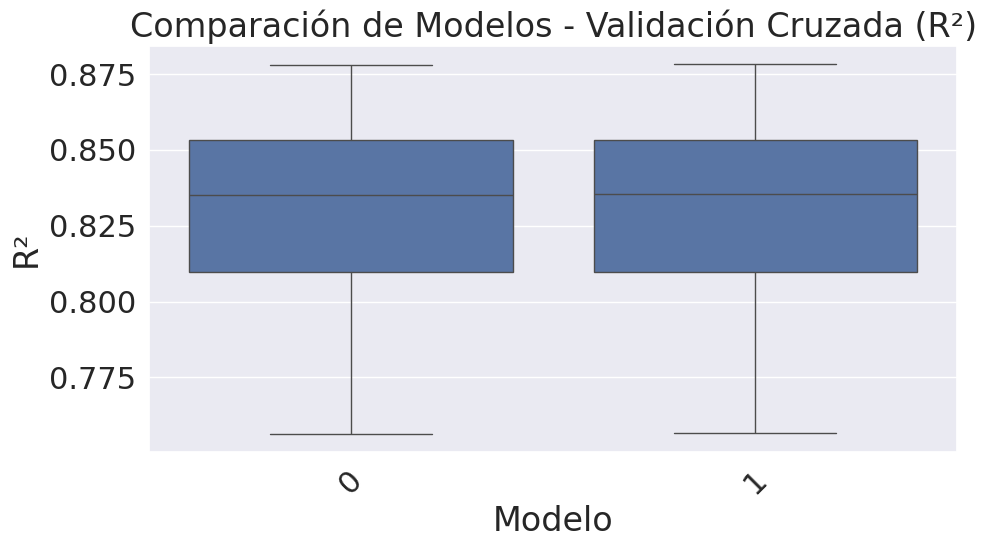

In [53]:
# Lista de fórmulas, resultados de mis dos modelso completo y reducido de regresion lineal
list_form_lineal = [form,form2]
list_form_lineal
# Aplicar cros val a la lista
list_res = pd.DataFrame(map(lambda x: cross_val_lin(x,df_mis_ItImp_random, seed=2022),list_form_lineal))
# Extraer el dataset y darle formato
# Trasnponer dataframe y pasar de wide a long (creando un factor variable con el nombre de cada fórmula de la lista[0,1,2,3])
results = list_res.T.melt()
results.columns = ['Modelo','R2']
results.head()
# Graficar boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Modelo', y='R2', data=results)
plt.title('Comparación de Modelos - Validación Cruzada (R²)')
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Concepto sesgo y varianza : El sesgo es 1- 0858 = 0.142, mi modelo tiene un sesgo moderado-bajo. Explica el 85,8% de la variabillidad, le falta explicar el 14.2%
En el caso de la varianza tiene una desviación standard de 0.012 lo que quiere decir que los resultados son consitentes entre diferentes muestras. Lo que buscabamos justo en este tipo de evaluaciones era un r2 alto con la menor desviación standard posible porque eso quiere decir que es consistente prediciendo con datos nuevos.
Como podemos ver tanto el modelo 0 como el 1 han obtenido los mismos resultados.

Modelo: plaga_severa ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas
Coeficiente de determinación R2: 0.132 (0.017)
Modelo: plaga_severa ~ lluvia_mm + temp_media_c + ph_suelo + materia_organica_pct + tipo_suelo + uso_pesticidas + historial_plagas
Coeficiente de determinación R2: 0.136 (0.016)


/tmp/ipykernel_4305/2078412269.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




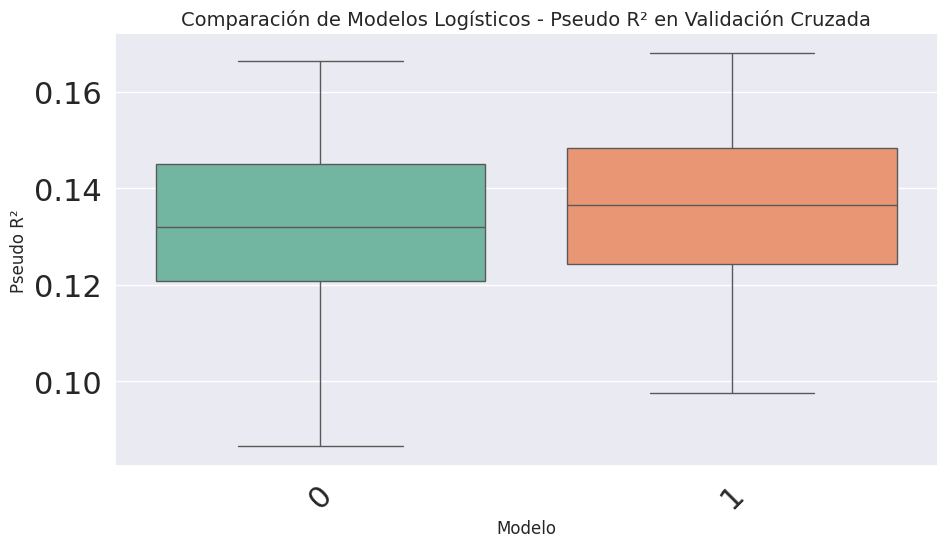

In [54]:
# Lista de fórmulas, resultados de mis dos modelso completo y reducido de regresion lineal
list_form_lineal = [form1_1,form2_2]
list_form_lineal
# Aplicar cros val a la lista
list_res = pd.DataFrame(map(lambda x: cross_val_lin(x,df_mis_ItImp_random_regresion, seed=2022),list_form_lineal))
# Extraer el dataset y darle formato
# Trasnponer dataframe y pasar de wide a long (creando un factor variable con el nombre de cada fórmula de la lista[0,1,2,3])
results = list_res.T.melt()
results.columns = ['Modelo','pseudo_r']
results.head()
# Graficar boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Modelo', y='pseudo_r', data=results, palette='Set2')
plt.title('Comparación de Modelos Logísticos - Pseudo R² en Validación Cruzada', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Pseudo R²', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En este caso ambos tienen un pseudo r similar siendo mejor el del segundo modelo. En cuanto al pseudo r2 es mejorable y de desviación standard ambos han obetenido una muy baja, por tanto son consistentes en su labor de predicción de resultados.

## Series temporales

Segunda parte sobre series temporales univariantes.

Los datos a utilizar en esta parte son los contenidos en el conjunto **IPI_Esp.xlsx**

### Pregunta 10

Convertir el conjunto de datos a una serie temporal comprensible para python.

- Análisis de los componentes de la serie temporal.
- ¿Dirías que es una serie estacionaria?



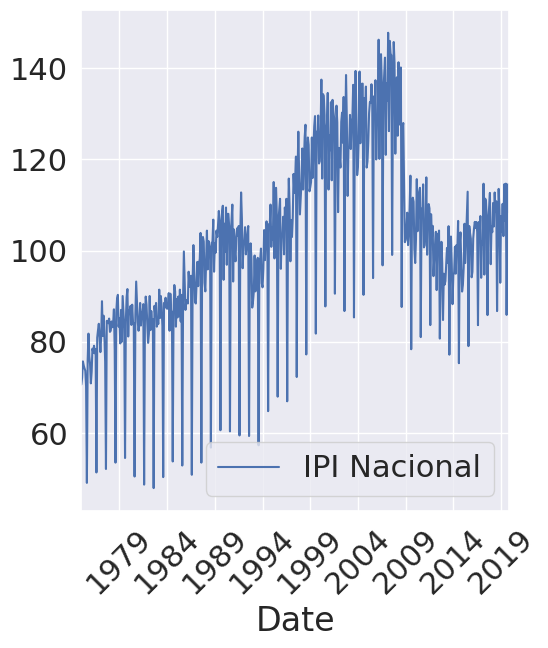

Results of Dickey-Fuller Test:
Test Statistic                  -1.781256
p-value                          0.389807
#Lags Used                      19.000000
Number of Observations Used    519.000000
Critical Value (1%)             -3.443013
Critical Value (5%)             -2.867125
Critical Value (10%)            -2.569745
dtype: float64


In [55]:
Air = pd.read_excel('/content/drive/MyDrive/mineria/tarea_mineria/IPI_Esp.xlsx')
# Conversión a serie temporal
Air.set_index(['Date'],inplace=True)
Air.index = pd.to_datetime(Air.index.str.strip().str.replace('M', '-'), format='%Y-%m')
Air.head()

# Componentes
plt.rcParams["figure.figsize"] = (6,7)
Air.plot()
plt.xticks(rotation=45)  # Rota las etiquetas
plt.tight_layout()        # Ajusta los márgenes automáticamente
plt.show()

# Prueba de estacionariedad
test_stationarity(Air)

**Respuestas**:

- Componentes : 1. Trend o tendencia :
Tiene pero no es sostenida. Se distinguen 3 fases:1975-2008: tendencia creciente sostenida ,2008-2013: caída fuerte por una crisis financiera,2013-2019: hay otro periodo conocido como de recuperación, pero no vuelve a ser como antes.
-Estacionalidad : Sí hay estacionalidad. Los picos  anuales son muy regulares y visibles durante toda la serie. Hay un patrón que se repite cada 12 meses.

3.Heterocedasticidad : La varianza parece aproximadamente constante, por lo que no hay evidencia clara de heterocedasticidad.

Con un p valor 0.38 no es estacionaria.
- ...


### Pregunta 11

Ajusta el modelo de suavizado exponencial que consideres más adecuado para el caso. Considerar la serie en escala original (sin tranformar).

- Análisis de los resultados.
- ¿Qué condición muy importante deben cumplir los residuos del modelo de series temporales? ¿Se satisface en este caso?



In [56]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing as ets

Tomamos las ventanas de training y test para ajuste y evaluación del modelo.

In [57]:
import statsmodels.tsa.holtwinters as ets
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Generamos la serie logaritmica
AirLog = Air.copy()
AirLog['IPI_Log'] = np.log(AirLog['IPI Nacional'])
AirLog

#parti original
Air_tr = Air[:'2017-12-01']  # Coge todo lo anterior
Air_tst = Air['2018-01-01':] # El resto
print(Air_tst)
#Partición log
Air_trLog = AirLog[:'2008-12-01']
Air_tstLog = AirLog['2009-01-01':]
print(Air_tstLog)

            IPI Nacional
Date                    
2018-01-01       105.313
2018-02-01       104.060
2018-03-01       110.466
2018-04-01       105.317
2018-05-01       112.755
2018-06-01       108.622
2018-07-01       110.835
2018-08-01        86.762
2018-09-01       103.342
2018-10-01       113.554
2018-11-01       108.957
2018-12-01        92.975
2019-01-01       107.589
2019-02-01       104.141
2019-03-01       110.276
2019-04-01       103.201
2019-05-01       114.570
2019-06-01       106.514
2019-07-01       114.698
2019-08-01        85.929
2019-09-01       106.408
2019-10-01       114.592
2019-11-01       108.464
            IPI Nacional   IPI_Log
Date                              
2009-01-01       102.372  4.628613
2009-02-01       104.528  4.649455
2009-03-01       108.334  4.685219
2009-04-01       101.230  4.617395
2009-05-01       103.894  4.643371
...                  ...       ...
2019-07-01       114.698  4.742303
2019-08-01        85.929  4.453521
2019-09-01       106.408 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



                       ExponentialSmoothing Model Results                       
Dep. Variable:             IPI Nacional   No. Observations:                  516
Model:             ExponentialSmoothing   SSE                           8987.247
Optimized:                         True   AIC                           1506.447
Trend:                         Additive   BIC                           1574.385
Seasonal:                Multiplicative   AICC                          1507.823
Seasonal Periods:                    12   Date:                 Sun, 24 May 2026
Box-Cox:                          False   Time:                         15:57:56
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2428497                alpha                 True
smoothing_trend          

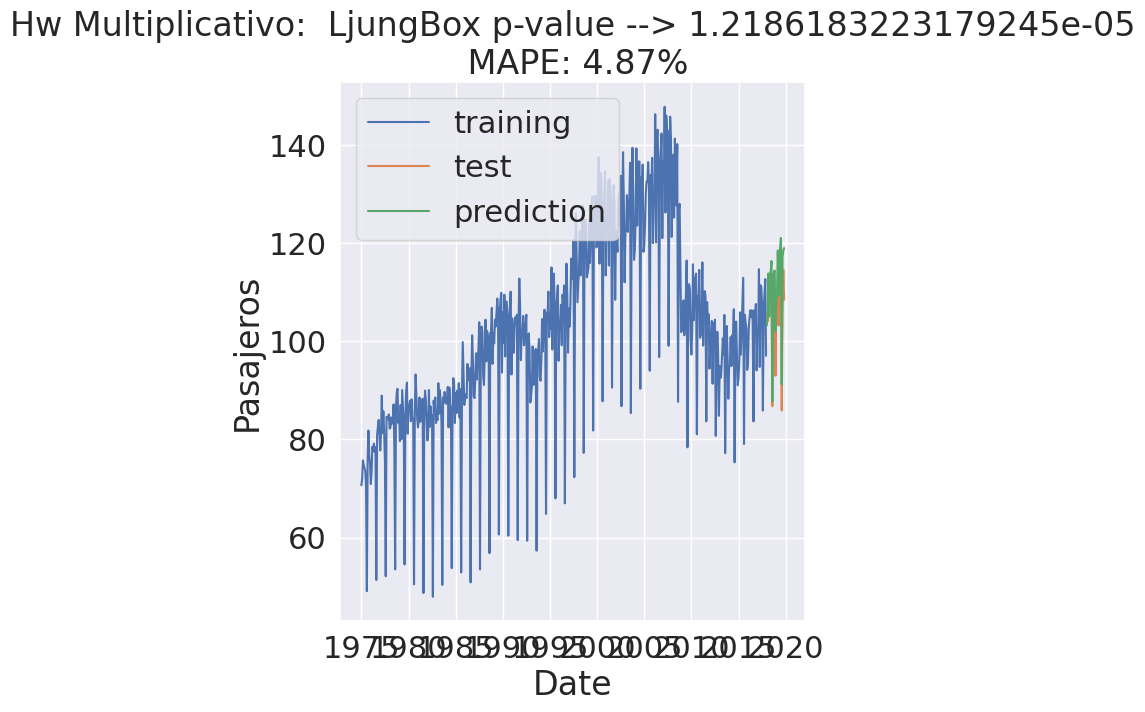

1.2186183223179245e-05


In [58]:
# Modelo de suavizado adecuado, holt winters multiplicativo
hw_mul = ets.ExponentialSmoothing(Air_tr,trend='add', damped_trend=False, seasonal='mul').fit()
print(hw_mul.summary())

eval_model(hw_mul,Air_tr,Air_tst,'Hw Multiplicativo')


 La condición fundamental es que los residuos del modelo se comporten como ruido blanco, es decir, que no presenten autocorrelación. En este caso, el test de Ljung-Box da un p-value de 1.218e-05,que es menor que 0.05, por lo que se rechaza la hipótesis nula de ausencia de autocorrelación. Si hay evidencia de que los residuos estén correlacionados.Por tanto, los residuos no son ruido blanco y el modelo no captura completamente la estructura de la serie.

### Pregunta 12

Ajusta el modelo Sarimax que la función autoarima considere más adecuado. Considerar la serie en escala original (sin tranformar).

- Análisis de los resultados.
- ¿Son significativos los parámetros?
- ¿Mejora la capacidad predictiva con respecto al suavizado anterior?
- ¿Qué contrasta el test de Ljung-Box? Decisión sobre $H_0$ en este caso.



In [59]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00


In [60]:
import pmdarima as pm
arima_auto = pm.auto_arima(Air_tr, start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=12,              # frequency of series (mensual)
                      d=None,           # let model determine 'd'
                      seasonal=True,   # No Seasonality
                      #start_P=None,
                      D=None,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)

print(arima_auto.summary())


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=2989.952, Time=4.94 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4372.087, Time=0.12 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=2.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3610.070, Time=2.24 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4370.092, Time=0.10 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=3611.462, Time=1.73 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=3088.364, Time=4.32 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=2973.607, Time=11.22 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=3066.562, Time=7.35 sec
 ARIMA(1,1,1)(2,0,2)[12] intercept   : AIC=2950.128, Time=16.67 sec
 ARIMA(1,1,1)(1,0,2)[12] intercept   : AIC=2958.683, Time=14.40 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=2978.941, Time=13.26 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=3046.169, Time=6.68 sec
 ARIMA(2,1,1)(2,0,2)[12] intercept   : AIC=2928.498, Time=7.31 sec
 ARIMA(2,1,1)(1,0,2)

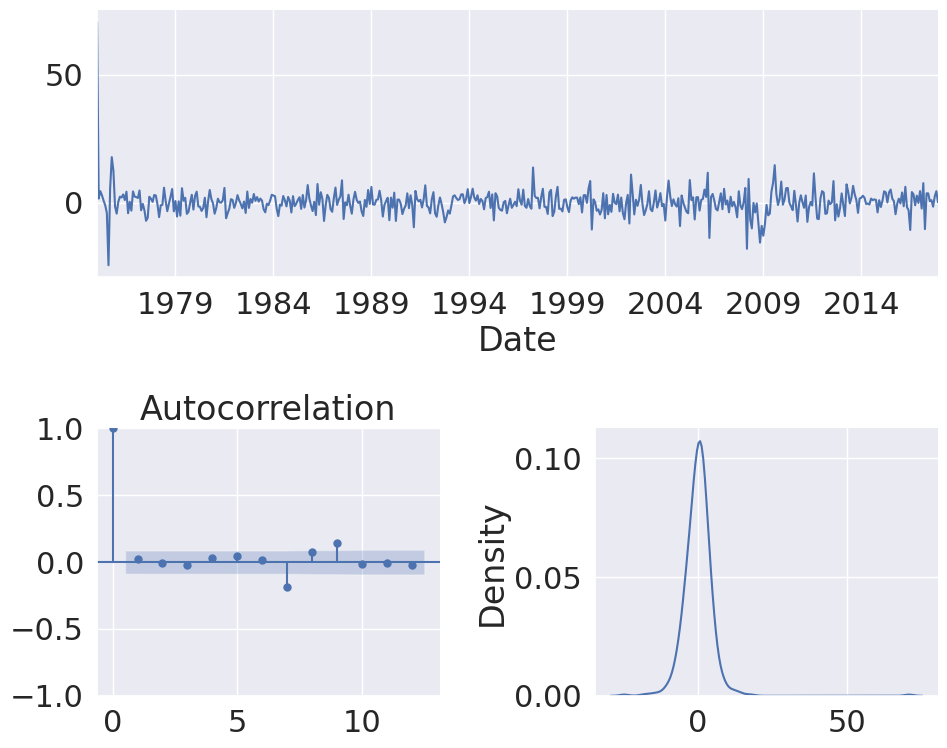

** Mean of the residuals:  0.15

** Ljung Box Test, p-value: 0.412 (>0.05, Uncorrelated)

** Jarque Bera Normality Test, p_value: 0.0 (<0.05, Not-normal)

** AD Fuller, p_value: 0.0 (<0.05, Stationary)


(<Axes: xlabel='Date'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: ylabel='Density'>)

In [61]:
residcheck(arima_auto.resid(),12)

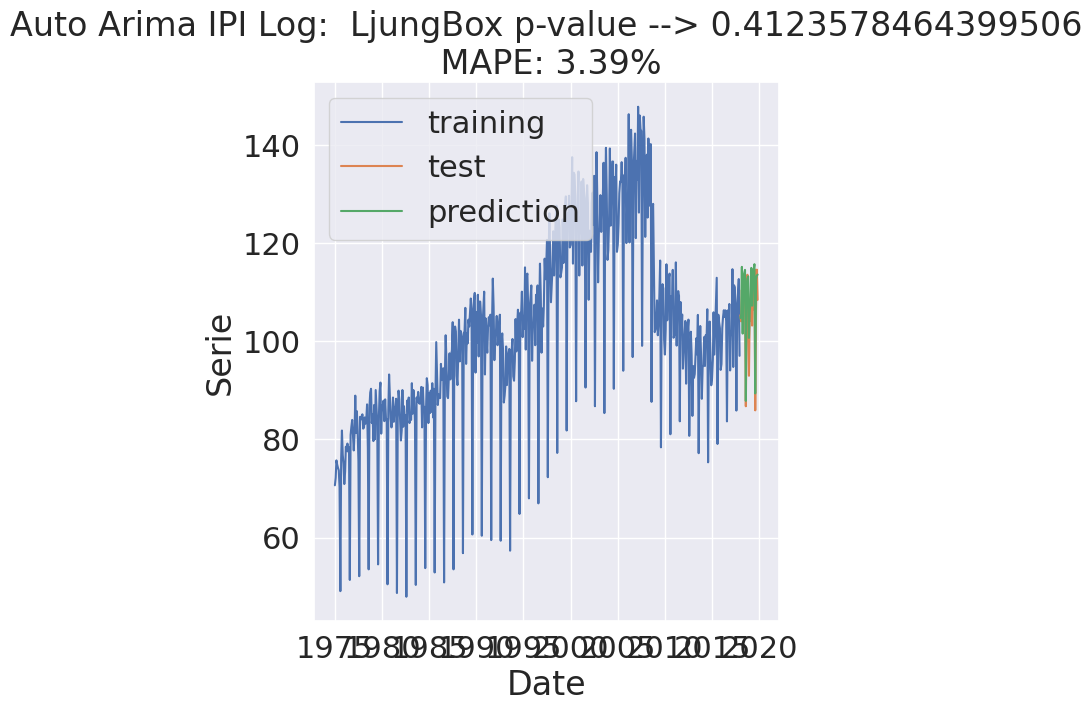

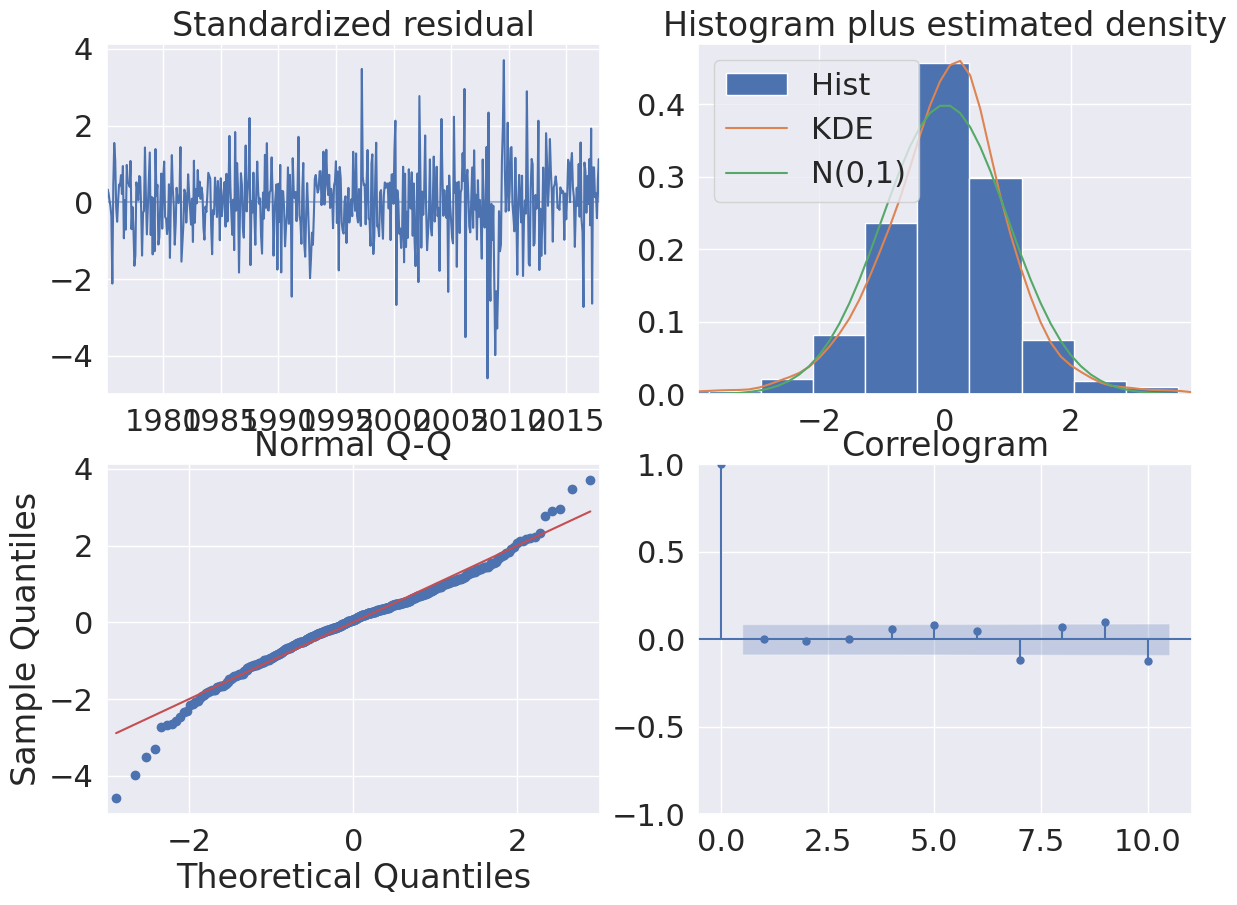

In [62]:
eval_model_Aarima(arima_auto,
                  Air_tr,
                  Air_tst,
                  'Auto Arima IPI Log')

Respuestas: - La mayoría de los parámetros son significativos p <0.05 excepto uno de ellos el ma.S.L12. El modelo es bueno en general, aunque este prámetro lo eliminaría para mejorarlo.

- Este modelo es mejor que el anterior porque elimina la autocorrelación residual, lo que indica que el modelo captura bien la estructura de la serie.

- El test de Ljung-Box constrasta si existe correlación en los residuos. Ho: los residuos no están autocorrelacionados, H1: los residuos están autocorrealcionados. 0.412 >0..05 por tanto no hay evidencia de que los residuos estén autocorrelacionados

## Técnicas no supervisadas

Esta es la última parte sobre técnicas no supervisadas. Importante la interpretación!

Los datos a utilizar en esta parte son los contenidos en el conjunto **Datos_drones_25.xlsx**

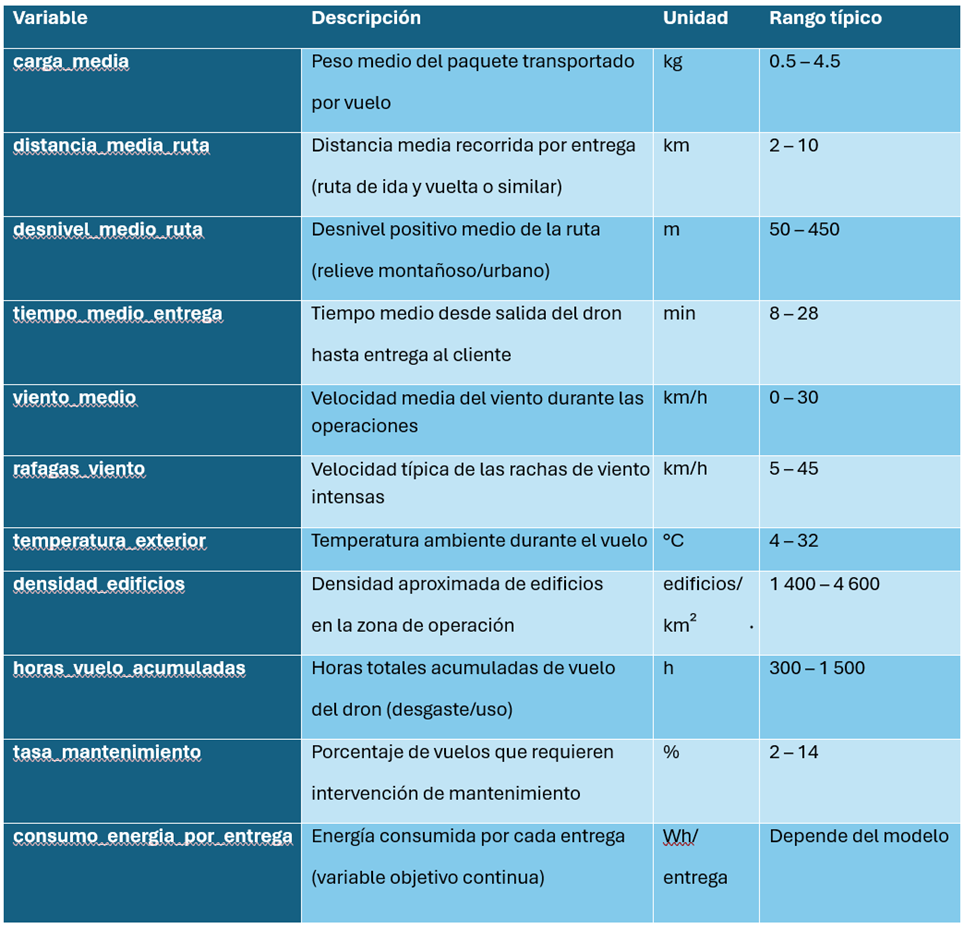

In [63]:
# Mostrar tabla de
from IPython.display import Image, display
display(Image(filename="/content/drive/MyDrive/mineria/tarea_mineria/Tabla_drones.png",width=600))
#lectura de datos
df_drones = pd.read_excel("/content/drive/MyDrive/mineria/tarea_mineria/Datos_drones_25.xlsx",index_col=0)

### Pregunta 13

Presentar la matriz de correlaciones entre las variables del conjunto de datos. Sabiendo que podría tratarse de un problema de regresión para estimar los valores de la variable objetivo `consumo_energia_por_entrega`:

- ¿Se intuye algún problema en ese posible modelo de regresión? Ponerle nombre y explicar causas y consecuencias.
- ¿Cómo podrías abordar el problema mediante la aplicación de alguna técnica no supervisada?



In [64]:
# Matriz de correlaciones
corr = df_drones.corr()
corr.style.background_gradient(cmap='viridis').format(precision=3)



,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento,consumo_energia_por_entrega
carga_media,1.000,-0.107,0.096,-0.910,-0.015,0.014,-0.122,-0.667,-0.075,0.368,0.871
distancia_media_ruta,-0.107,1.000,-0.932,0.341,0.900,-0.899,0.663,0.098,-0.041,0.094,0.077
desnivel_medio_ruta,0.096,-0.932,1.000,-0.309,-0.842,0.841,-0.622,-0.094,0.026,-0.101,-0.035
tiempo_medio_entrega,-0.910,0.341,-0.309,1.000,0.252,-0.251,0.291,0.631,0.050,-0.301,-0.761
viento_medio,-0.015,0.900,-0.842,0.252,1.000,-0.999,0.632,0.029,-0.025,0.102,0.130
rafagas_viento,0.014,-0.899,0.841,-0.251,-0.999,1.000,-0.631,-0.028,0.026,-0.102,-0.130
temperatura_exterior,-0.122,0.663,-0.622,0.291,0.632,-0.631,1.000,0.103,0.002,0.042,-0.174
densidad_edificios,-0.667,0.098,-0.094,0.631,0.029,-0.028,0.103,1.000,0.045,-0.212,-0.589
horas_vuelo_acumuladas,-0.075,-0.041,0.026,0.050,-0.025,0.026,0.002,0.045,1.000,-0.022,-0.062
tasa_mantenimiento,0.368,0.094,-0.101,-0.301,0.102,-0.102,0.042,-0.212,-0.022,1.000,0.342


**Respuestas**:

- Si multicolinealidad. Causas : variables relacionadas entre sí, variables que se han construido a partir de otras como por ejemplo haciendo uso de transformaciones. Consecuencias : dificultad para evaluar la importancia relativa de las variables, los coeficientes pueden ser erróneos teniendo el signo contrario al que se esperaba.
- Podría abordarlo mediante PCA que consiste en que una vez que sabemos que la variables están correlacionadas entre si, las transformamos en un nuevo conjunto de variables que se llaman componentes que resumen toda la información común con el matiz de que lo hacen sin la redundancia. Las nuevas componentes no están correlacionadas entre si.


### Pregunta 14

Calcular el KMO de la muestra para todas las variables excepto la objetivo (y si existen identificadores o variables rechazadas).

- Interpretar los resultados adecuadamente.
- ¿Es adecuado reducir la dimensionalidad del input de predictores del problema?
- En caso afirmativo, aplica la reducción y decide el número de componentes a retener en la solución.
- Presenta el gráfico adecuado e interpreta las componentes (nombre y caracterización tentativa)


In [66]:
!pip install factor-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=3db40be484715a6b85d31db33b374b166fc94bec5811bfe9d4b1a5e5f58e863e
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor-analyzer


In [67]:
# KMO
from factor_analyzer.factor_analyzer import calculate_kmo
print(calculate_kmo(df_drones))

calculate_kmo(df_drones.drop(['horas_vuelo_acumuladas','consumo_energia_por_entrega'], axis=1))
#primer output con todas las varaibles segundo con las dos eliminadas que tenían un kmo bajo como horas_de_vuelo acumuladas 0.43 y consumo_energia tenia 0.67 y eliminandola mejora el kmo de 0.76 a 0.78


(array([0.67983762, 0.76695453, 0.80897355, 0.81924136, 0.75084107,
       0.75105283, 0.76537743, 0.97078447, 0.43309071, 0.95658297,
       0.67444405]), np.float64(0.7654938195472731))


(array([0.62503552, 0.84372734, 0.84443677, 0.68205644, 0.74948364,
        0.75010561, 0.98304639, 0.93451688, 0.91482159]),
 np.float64(0.7866786831225968))

- Decido sacar horas_vuelo_acumuladas porque el valor 0.43 es bajo, y consumo_energia tenía 0,67 y me quedo con un valor de 0.78 de KMO total. Probé a eliminar carga_media pero me bajaba el kmo de otra variable a 0.56. KMO individual es bueno si es >0.7 y general lo mismo.

-Con las 9 variables predictoras restantes se obtiene un kmo de 0.78 es totalmente adecuado reducir dimensionalidad.

PCA con el paquete pca

In [68]:
! pip install pca

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 6.3 MB/s eta 0:00:00


Inicializo la siguiente celda sin n_components y veo que entre 2 y 3 componentes la diferencia es bastante significativa como para tener 3 componentes en cuenta, entonces determino el número 3 pen n_components una celda más abajo para que el modelo tengo en cuenta 3. Para saber exactamente la diferencia de varianza entre 3 y 2 ejecuto con 3 y leugo con 2 n_components y veo la diferencia exacta en términos de porcentaje. Observo que es 9,32 % lo que es bastante, por eso decido elegir 3.

[24-05-2026 16:03:46] [pca.pca] [INFO] Extracting column labels from dataframe.
[24-05-2026 16:03:46] [pca.pca] [INFO] Extracting row labels from dataframe.
[24-05-2026 16:03:46] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[24-05-2026 16:03:46] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 11 columns of the input data.
[24-05-2026 16:03:46] [pca.pca] [INFO] Fit using PCA.
[24-05-2026 16:03:46] [pca.pca] [INFO] Compute loadings and PCs.
[24-05-2026 16:03:46] [pca.pca] [INFO] Compute explained variance.
[24-05-2026 16:03:46] [pca.pca] [INFO] The top 6 principal component(s) explains >= 95.00% of the explained variance.
[24-05-2026 16:03:46] [pca.pca] [INFO] The PCA reduction is performed on 11 variables (columns) of the input dataframe.
[24-05-2026 16:03:46] [pca.pca] [INFO] Fit using PCA.
[24-05-2026 16:03:46] [pca.pca] [INFO] Compute loadings and PCs.
[24-05-2026 16:03:46] [pca.pca] [INFO] Outlier det

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Cumulative explained variance.\n The top 6 Principal Component(s) explains [95.81%] of the variance.'}, xlabel='Principal Component', ylabel='Percentage explained variance'>)

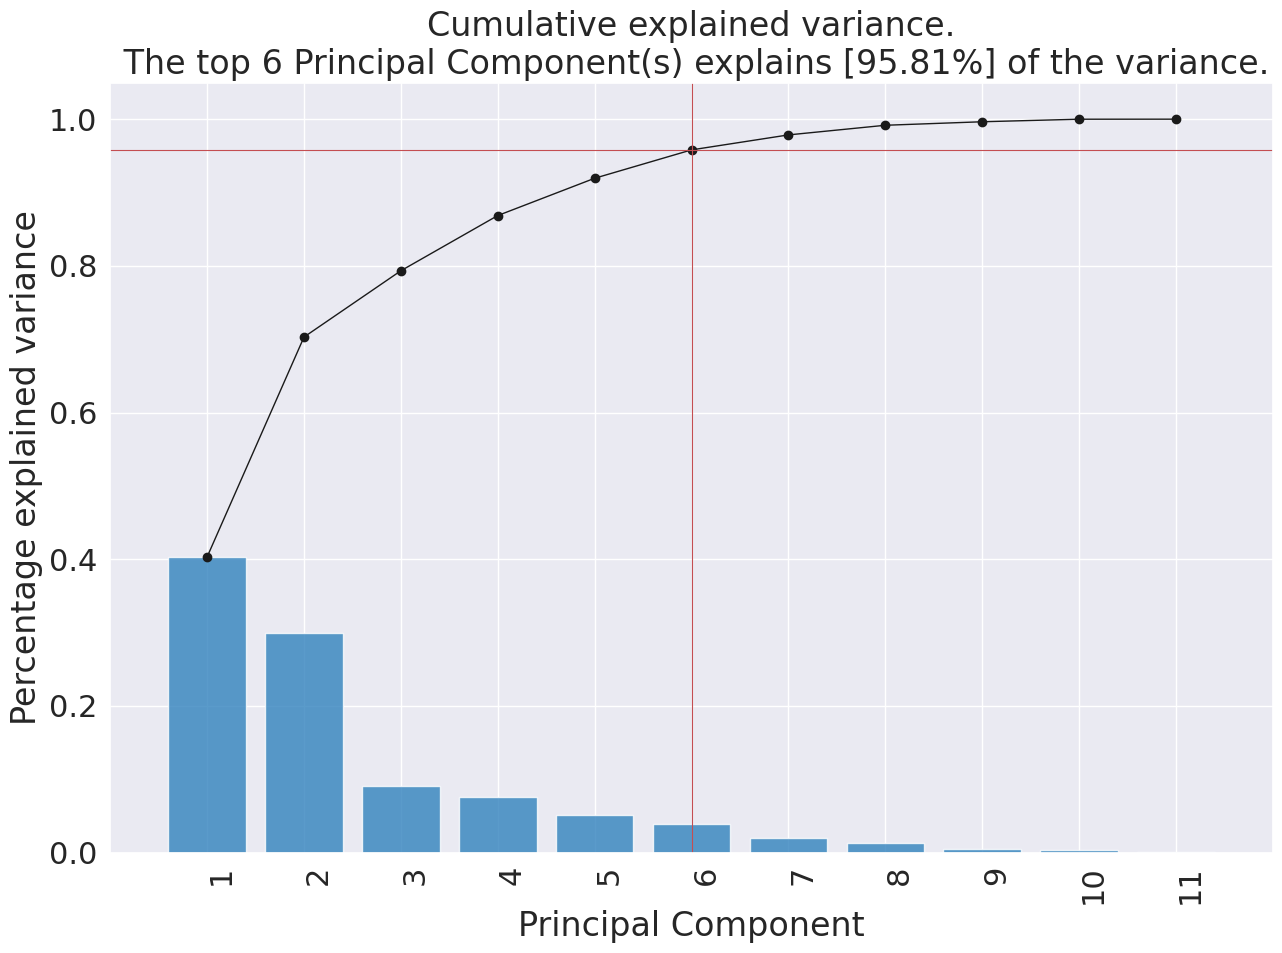

In [69]:
from pca import pca

# Initialize pca with default parameters
model = pca(normalize=True)
#controlo cuantas componentes me quedo, estoy con 2 componentes recogiendo el 70% de la variabilidad
# Fit transform
results = model.fit_transform(df_drones)

# Plot the explained variance
model.plot()


[24-05-2026 16:03:50] [pca.pca] [INFO] Extracting column labels from dataframe.
[24-05-2026 16:03:50] [pca.pca] [INFO] Extracting row labels from dataframe.
[24-05-2026 16:03:50] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[24-05-2026 16:03:50] [pca.pca] [INFO] The PCA reduction is performed on 11 variables (columns) of the input dataframe.
[24-05-2026 16:03:50] [pca.pca] [INFO] Fit using PCA.
[24-05-2026 16:03:50] [pca.pca] [INFO] Compute loadings and PCs.
[24-05-2026 16:03:50] [pca.pca] [INFO] Compute explained variance.
[24-05-2026 16:03:50] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[3]
[24-05-2026 16:03:51] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-05-2026 16:03:51] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]


(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Cumulative explained variance.\n The top 3 Principal Component(s) explains [79.32%] of the variance.'}, xlabel='Principal Component', ylabel='Percentage explained variance'>)

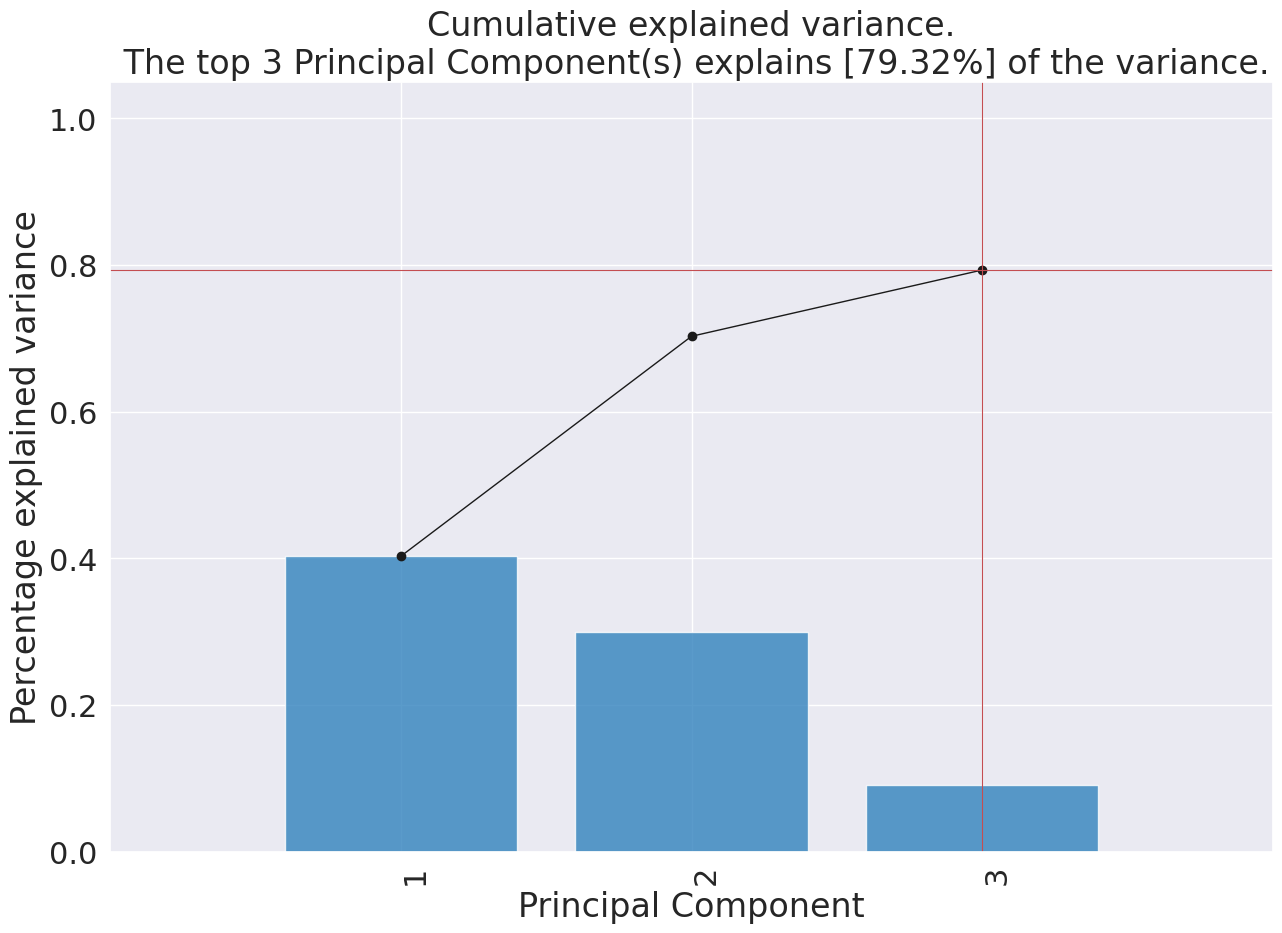

In [70]:
from pca import pca

# Initialize pca with default parameters
model = pca(normalize=True, n_components=3) #indicando el num de componentes ya estoy reduciendo dimensionalidad
#controlo cuantas componentes me quedo, estoy con 2 componentes recogiendo el 70% de la variabilidad, y con 3 el 79,32%
# Fit transform
results = model.fit_transform(df_drones)#fit que se adapte a mi data que es df drones y transform para transformarla.

# Plot the explained variance
model.plot()


Gracias a la reducción de dimensionalidad sé que me puedo quedar con tres componentes porque explican un 9,32% de varianza más que quedarme solo con dos variables, y por este aumento, merece la pena.

In [71]:
model.results#para ver kas cargas, vemos pc1, pc2 y pc3

{'loadings':      carga_media  distancia_media_ruta  desnivel_medio_ruta  \
 PC1    -0.164678              0.442684            -0.426236   
 PC2     0.493876              0.140583            -0.133681   
 PC3     0.010321             -0.012931            -0.001512   
 
      tiempo_medio_entrega  viento_medio  rafagas_viento  temperatura_exterior  \
 PC1              0.266392      0.428828       -0.428355              0.357782   
 PC2             -0.417323      0.185141       -0.185480              0.049788   
 PC3             -0.019737      0.010628       -0.010297              0.031102   
 
      densidad_edificios  horas_vuelo_acumuladas  tasa_mantenimiento  \
 PC1            0.139704               -0.003463           -0.004736   
 PC2           -0.392038               -0.056744            0.272619   
 PC3           -0.018583                0.994919            0.087545   
 
      consumo_energia_por_entrega  
 PC1                    -0.096588  
 PC2                     0.491834  
 P

In [72]:
model.results['loadings'].T#cojo las cargas para cada una de las componentes y aqui tengo 3, y puedo ver como cada valor infiere en cada uno de las componentes PC1,2 o 3. Analizar las cargas para ver que significa mcada componente.
#las tres componentes son variables que resumen las anteriores 11 variables.
#las cargas indican cuánto aporta cada variable original a cada componente.
#loading es la clave para nombras las componentes.

,PC1,PC2,PC3
carga_media,-0.164678,0.493876,0.010321
distancia_media_ruta,0.442684,0.140583,-0.012931
desnivel_medio_ruta,-0.426236,-0.133681,-0.001512
tiempo_medio_entrega,0.266392,-0.417323,-0.019737
viento_medio,0.428828,0.185141,0.010628
rafagas_viento,-0.428355,-0.185480,-0.010297
temperatura_exterior,0.357782,0.049788,0.031102
densidad_edificios,0.139704,-0.392038,-0.018583
horas_vuelo_acumuladas,-0.003463,-0.056744,0.994919
tasa_mantenimiento,-0.004736,0.272619,0.087545


- Respuesta nombres de componentes : Podemos ver en las cargas que PC1 recoge factores geográficos como distancia_media_ruta y desnivel_medio_ruta,climáticos como viento pc1 de 0.42, rafagas_viento, temperatura. PC1 = Factor geográfico-climático que diferencia entre rutas de llanura y rutas de montaña

- PC2 es carga_media(kg del paquete), tiempo_medio_entrega,densidad de edificios,tasa_mantenimiento,consumo_energía_por_entrega. PC2 = Eficiencia de entregas en zonas rurales vs en zonas de ciudad(esto último lo da la densidad de los edificios). PC3 = horas de vuelo acumuladas. El desgaste del dron.

In [73]:
nuevo_data = model.results['PC']#estos son los scores de cada uno de los trayectos de entrega del dron
nuevo_data.head()


,PC1,PC2,PC3
0,-2.277949,0.591858,-0.031064
1,-2.009679,-3.098346,0.016851
2,-0.864384,-2.747357,-0.922553
3,1.296811,-1.098893,-0.208974
4,-0.407977,1.930075,-2.221886


Por ejemplo para el trayecto 0, en pc1 está negativo por lo que es una ruta de montaña, pc2 positivo es una entrega rural y el pc3 las horas de vuelo acumuladas, el desgaste del dron. Y más desarrollado : Para el trayecto 0 el pc1 es -2.27 en una ruta de montaña con mayor desnivel y presencia de ráfagas, menor distancia y menor viento constante. El pc2 es positivo 0.59 paquetes que tienen un peso mayor, con más consumo energético, menos edificios y entregas menor tiempo de entrega, entregas más rápidas.

[24-05-2026 16:04:02] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[24-05-2026 16:04:02] [scatterd.scatterd] [INFO] Create scatterplot


(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': 'The top 3 Principal Component(s) explains [79.32%] of the variance.'}, xlabel='PC1 (40.3% expl.var)', ylabel='PC2 (29.9% expl.var)'>)

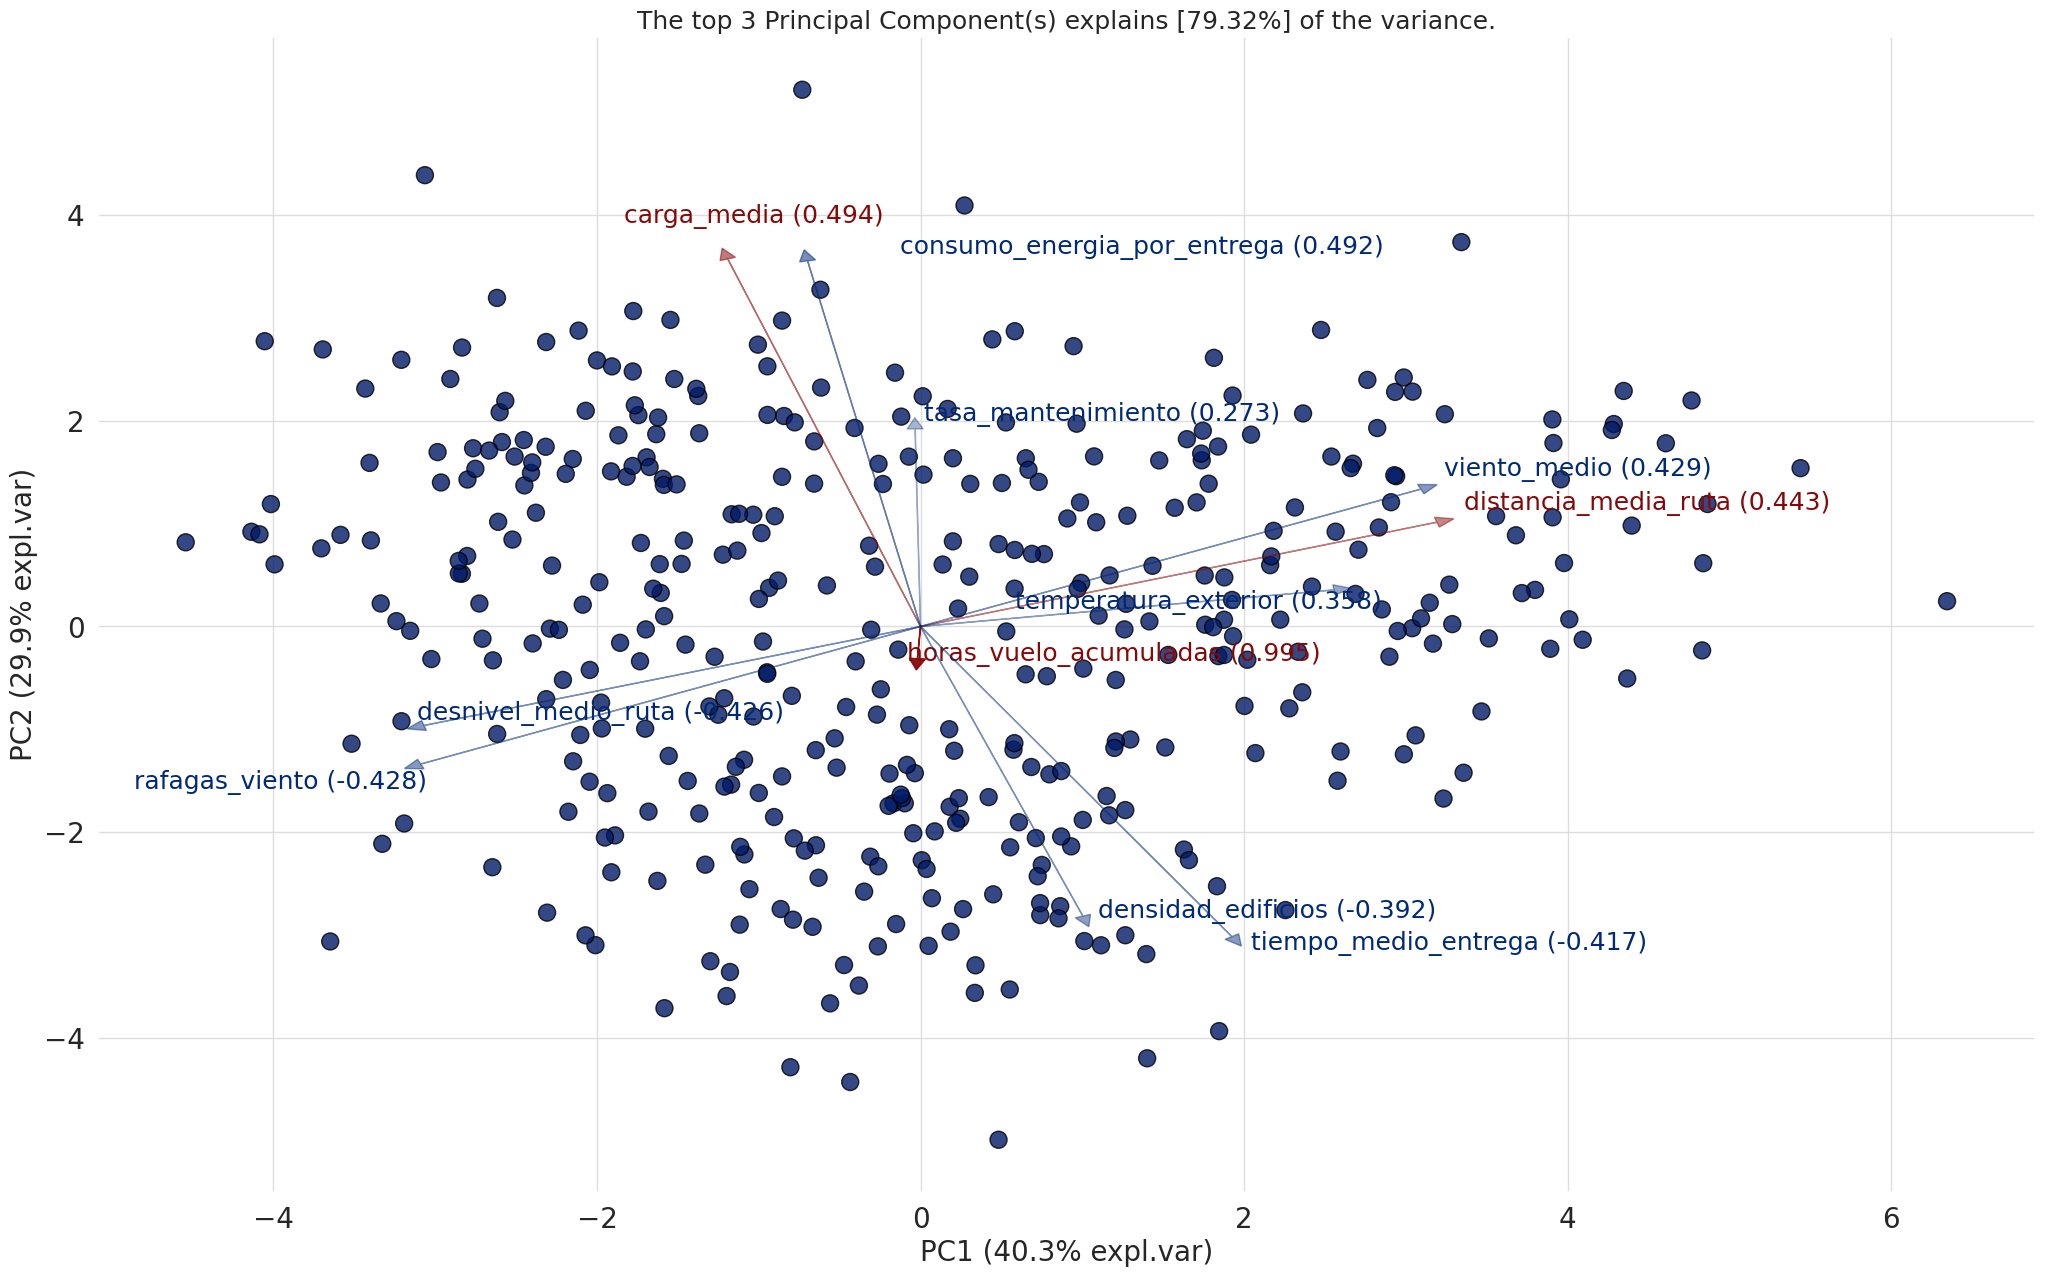

In [74]:
# Plot the explained variance
model.biplot(legend=False, labels=df_drones.index)
#plt.show()
#reparto area queda repartida
#internamente usa results['PC'] que son mis tres componentes y para eituqetas usa la data para nombrar cada punto

Respuesta : Caracterización tentativa.

PC1 = Factor geográfico-climático que diferencia entre rutas de llanura y rutas de montaña

PC2 = Eficiencia de entregas en zonas rurales vs en zonas de ciudad

PC3 = horas de vuelo acumuladas.El desgaste del dron

Cuando PC2 toma valores negativos, la densidad de edificios y el tiempo medio de entrega aumentan, lo que sugiere entornos urbanos, la carga media y el consumo energético bajan. Cuando toma valores positivos sugiere que estamos en entornos rurales con cargas_media mayores osea cargas más pesadas y un consumo_energía mayor, menos edificios y tiempos de entrega menores.. Se ha determinado la parte positiva como rural porque es lo contrario de lo que nos dice la flecha de abajo de densidad_edificios. Si allí es mayor lo contrario es menor densidad de edificios y por tanto entorno rural.

Cuando Pc1 toma valores positivos estamos en entornos de llanura, donde la distancia-media de ruta aumenta,es larga el viento_medio es alto y la temperatura también aumenta.El desnivel medio y las ráfagas de viento son menores.Cuando toma valores negativos, estamos en entorno de montaña con desnivel y ráfagas de viento mayores, distancias menores y menor viento medio.

PC3 es independiente de PC1 y PC2, puede haber drones con más o menos horas de vuelo acumuladas en cualqueir tipo de ruta, no depende de si vuelvas en ciudad o áreas rurales y tampoco depende de si es montaña o llanura.

En cuanto a los signos por ejemplo en el caso de densidad de edificios, no significa la densidad de edificios es baja si no que la flecha apunta hacia abajo.

En la interpretación no se puede mezclar PC1 con PC2. En PCA, los componentes principales son ortogonales (independientes) entre sí. Eso significa que Principal Component PC1 y PC2 no están correlacionados.

**Respuestas**:



### Pregunta 15
basada en ejemplo clustering países
Considerando la los resultados del apartado anterior, la solución en dimensión reducida, aplicar un modelo de clustering particional y decidir el número de grupos que resultan más adecuados.

- ¿Qué valor toman la silueta y el % de variabilidad explicada de la soución?
- Presentar centroides.
- Gráfico biplot de resultados por grupos formados (en colores).
- Caratcerizar adecuadamente los grupos creados (mencionando a las componentes principales obtenidas en el apartado anterior)


In [83]:
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist, pdist
import matplotlib.pyplot as plt
import numpy as np

In [84]:
# Rescatar los scores del PCA para el número de componentes seleccionadas
nuevo_data = model.results['PC']#3 componentes
nuevo_data.head()


,PC1,PC2,PC3
0,-2.277949,0.591858,-0.031064
1,-2.009679,-3.098346,0.016851
2,-0.864384,-2.747357,-0.922553
3,1.296811,-1.098893,-0.208974
4,-0.407977,1.930075,-2.221886


Clustering jerárquico : Los métodos de clustering jerárquico servirán para hacerse una idea de la dinámica de agrupación de los datos y proponer, en base al dendograma, un número de grupos tentativos que presenten características comunes.

Vamos a definir una función que facilite la creación del dendograma dado el modelo jerárquico que se desee visualizar.


In [85]:
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np

def scree_plot_kmeans(data, n_max):
    range_n_clusters = range(2, n_max)
    X_scaled = scale(nuevo_data)

    inertias = []
    silhouette = []
    var_perc = []

    for n_clusters in range_n_clusters:
        modelo_kmeans = KMeans(
            n_clusters=n_clusters,
            n_init=20,
            random_state=123
        )
        cluster_labels = modelo_kmeans.fit_predict(X_scaled)

        inertias.append(modelo_kmeans.inertia_)
        silhouette.append(silhouette_score(X_scaled, cluster_labels))

        tss = sum(pdist(X_scaled)**2) / X_scaled.shape[0]
        bss = tss - modelo_kmeans.inertia_
        var_perc.append(bss / tss * 100)

    fig, ax = plt.subplots(1, 3, figsize=(16, 6))

    ax[0].plot(range_n_clusters, inertias, marker='o')
    ax[0].set_title("Scree plot - Varianza intra")
    ax[0].set_xlabel('Número clusters')
    ax[0].set_ylabel('Intra-cluster (inertia)')
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(range_n_clusters, silhouette, marker='o')
    ax[1].set_title("Scree plot - Silhouette")
    ax[1].set_xlabel('Número clusters')
    ax[1].set_ylabel('Media índices silhouette')
    ax[1].grid(True, alpha=0.3)

    ax[2].plot(range_n_clusters, var_perc, marker='o')
    ax[2].set_title("Scree plot - % Varianza explicada")
    ax[2].set_xlabel('Número clusters')
    ax[2].set_ylabel('% de varianza explicada')
    ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

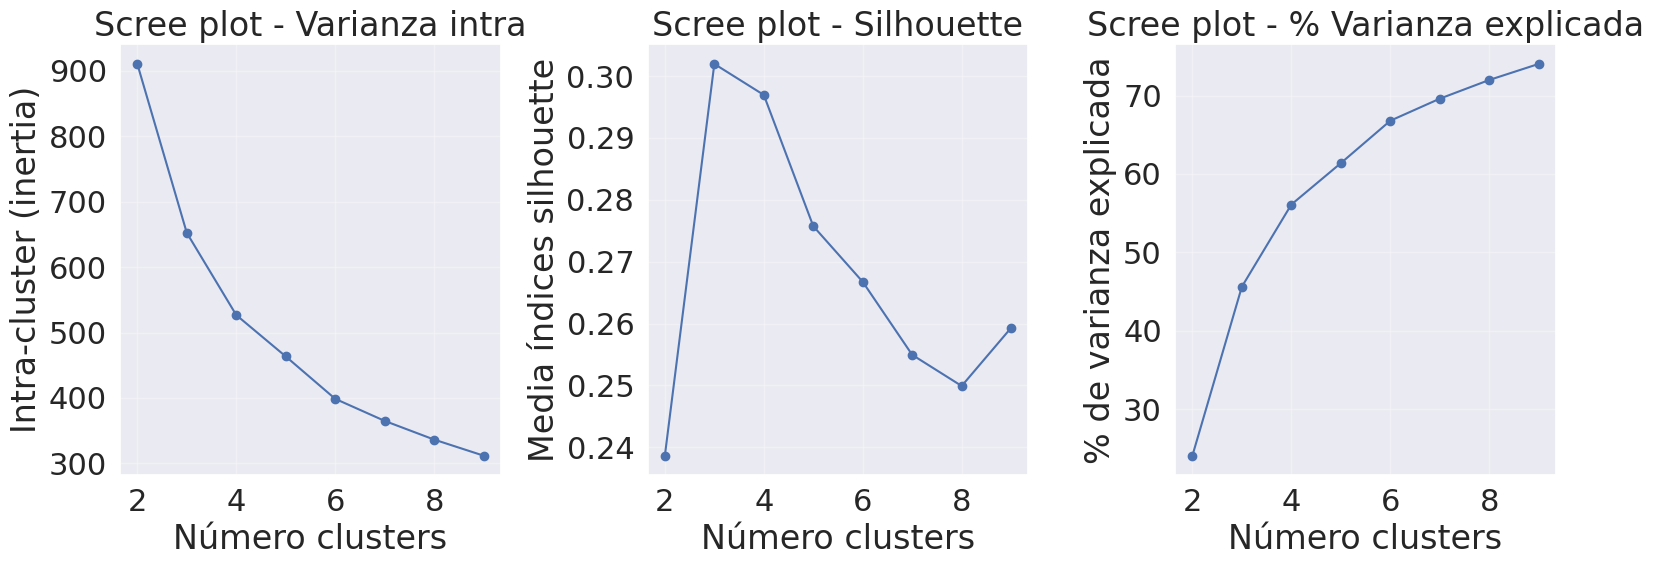

In [86]:
scree_plot_kmeans(nuevo_data, 10)
plt.show()

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_drones)  # o tu DataFrame original

# 2. KMeans
modelo_kmeans = KMeans(n_clusters=3, n_init=25, random_state=123)
modelo_kmeans.fit(X=X_scaled)

# 3. Centroides
print('Centroides')
print(modelo_kmeans.cluster_centers_)

# 4. Gráfico (tu código ya está correcto)
import plotly.express as px
import pandas as pd

df_plot = pd.DataFrame(
    nuevo_data,
    columns=['PC1', 'PC2', 'PC3']
)
df_plot['cluster_kmeans'] = modelo_kmeans.labels_
df_plot['trayecto'] = df_drones.index

fig = px.scatter(
    df_plot,
    x='PC1',
    y='PC2',
    color='cluster_kmeans',
    text='trayecto',
    height=600,
    title='Clusters k-means en espacio PC1 vs PC2'
)
fig.update_traces(textposition='top center')
fig.update_layout(legend_title_text='Cluster')
fig.show()

Centroides
[[-0.98518787 -0.46756831  0.44126086  0.78372089 -0.52228995  0.52487303
  -0.20109259  0.71925699  0.13045375 -0.47306219 -0.99185827]
 [ 1.01188405 -0.6591217   0.61934391 -1.09281353 -0.55089331  0.54939977
  -0.54734863 -0.722153   -0.05652135  0.35859383  0.81824051]
 [-0.02902679  1.22505184 -1.15319725  0.33607692  1.16687386 -1.16805852
   0.81378133  0.00314884 -0.08038681  0.12446163  0.18877486]]


el grupo azul y amarillo representan el entorno rural, con la diferencia de que el amarillo habla de la llanura y el azul de un terreno montañoso. En cambio el grupo amarillo nos presenta un grupo de trayectos relacionados en zonas de ciudad con características como una mayor densidad de edificios y mayor tiempos medio de entrega.

El cuadrante de abajo a la izquierda habla de trayectos realcionados en ciudad pero estas tienen características de desnivel y de mayores ráfagas de viento. Pueden ser ciudades construidas sobre pinares por ejemplo.

El cuadrante de abajo a la derecha muestra ciudades con vientos medios superiores y mayor distancia media de ruta, son ciudades más llanas en las que también aumenta más la temperatura.

Cuadrante de arriba a la izquierda son zonas rurales con montañas y el cuadrante de arriba a la derecha zonas rurales pero en este caso son llanas